In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import pickle
from scipy.optimize import brentq, root, minimize_scalar
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

SMALL_SIZE = 18
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):

    current_directory = os.getcwd()
    if current_directory.endswith(directory):
        pass
    else:
        os.chdir(directory)
    # initilize data list
    S2_scalar = np.zeros(len(aspect_ratios))
    S4_scalar = np.zeros(len(aspect_ratios))
    biaxiality = np.zeros(len(aspect_ratios))
    theta_d = np.zeros(len(aspect_ratios))
    phi = np.zeros(len(aspect_ratios))
    bin_centers = np.zeros((len(aspect_ratios), 100))
    pdf_data = np.zeros((len(aspect_ratios), 100))
    U_fitted = np.zeros(len(aspect_ratios))
    phi_fluctuations = np.zeros(len(aspect_ratios))
    D_r = np.zeros(len(aspect_ratios))
    shear_rate = np.zeros(len(aspect_ratios))
    rmse = np.zeros(len(aspect_ratios))
    n1_diff = np.zeros(len(aspect_ratios))
    n2_diff = np.zeros(len(aspect_ratios))
    p_yy = np.zeros(len(aspect_ratios))
    p_xy = np.zeros(len(aspect_ratios))
    S2_tensor = np.zeros((len(aspect_ratios), 3, 3))
    S4_tensor = np.zeros((len(aspect_ratios), 3, 3, 3, 3))
    strains = np.zeros((len(aspect_ratios), 3200))
    S2_over_time = np.zeros((len(aspect_ratios), 3200))
    biaxiality_over_time = np.zeros((len(aspect_ratios), 3200))
    angle_over_time = np.zeros((len(aspect_ratios), 3200))
    times = np.zeros((len(aspect_ratios), 510))
    oacf = np.zeros((len(aspect_ratios), 510))
    tau_r = np.zeros(len(aspect_ratios))
    A_infty = np.zeros(len(aspect_ratios))
    omega = np.zeros((len(aspect_ratios), 3))
    screening_jeffrey = np.zeros(len(aspect_ratios))
    error_screening = np.zeros(len(aspect_ratios))
    theta_bins = np.zeros((len(aspect_ratios), 15))
    omega_bins = np.zeros((len(aspect_ratios), 15))
    std_omega_bins = np.zeros((len(aspect_ratios), 15))

    for idx, ap in enumerate(aspect_ratios):
        filename = f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl'
        if os.path.exists(filename):
            with open(filename, 'rb') as file:
                file_data = pickle.load(file)
                bin_centers[idx, :] = file_data['bin_centers']
                pdf_data[idx, :] = file_data['f_data']
                S2_scalar[idx] = file_data['S2_scalar']
                S4_scalar[idx] = file_data['S4_scalar']
                biaxiality[idx] = file_data['biaxiality']
                theta_d[idx] = file_data['theta_d']
                U_fitted[idx] = file_data['U_fitted']
                phi[idx] = file_data['phi']
                phi_fluctuations[idx] = file_data['phi_fluct']
                D_r[idx] = file_data['D_r']
                shear_rate[idx] = file_data['shear_rate']
                rmse[idx] = file_data['rmse_fit']
                n1_diff[idx] = file_data['Nx_diff']
                n2_diff[idx] = file_data['Nz_diff']
                p_yy[idx] = file_data['p_yy']
                p_xy[idx] = file_data['p_xy']
                S2_tensor[idx, :, :] = file_data['nematic_tensor']
                S4_tensor[idx, :, :, :, :] = file_data['S4']
                strains[idx, :len(file_data['strains'])
                        ] = file_data['strains']  # zeros in the end
                S2_over_time[idx, :len(file_data['strains'])
                             ] = file_data['S2_over_time']
                biaxiality_over_time[idx, :len(
                    file_data['strains'])] = file_data['biaxility_over_time']
                angle_over_time[idx, :len(
                    file_data['strains'])] = file_data['angle_over_time']
                times[idx, :len(file_data['times'])] = file_data['times']
                oacf[idx, :len(file_data['times'])] = file_data['oacf']
                tau_r[idx] = file_data['tau_r']
                A_infty[idx] = file_data['A_infty']
                omega[idx, :] = file_data['ave_omega'] * shear_rate[idx]**2
                screening_jeffrey[idx] = file_data['screening_jeffrey']
                error_screening[idx] = file_data['error_screening']
                theta_bins[idx, :] = file_data['theta_bins']
                omega_bins[idx, :] = file_data['omega_bins']
                std_omega_bins[idx, :] = file_data['std_omega_bins']

    os.chdir('..')  # return to the original directory
    return (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, theta_d, U_fitted,
            phi, phi_fluctuations, D_r, shear_rate, rmse, n1_diff, n2_diff, p_yy, p_xy,
            S2_tensor, S4_tensor, strains, S2_over_time, times, oacf, tau_r, A_infty,
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time)


def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)


def P4(x):
    """Calculates the fourth Legendre polynomial, P₄(x)."""
    return 0.125 * (35 * x**4 - 30 * x**2 + 3)


def P6(x):
    """Calculates the sixth Legendre polynomial, P₆(x)."""
    return (1/16) * (231 * x**6 - 315 * x**4 + 105 * x**2 - 5)


def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)

    legendre_term = P2(cos_thetas)

    numerator = np.exp(S * U * legendre_term)

    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)

    return numerator / denominator


def fit_equilibrium_ODF_P4(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using both P₂ and P₄ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄) / Z
    """
    S2, S4 = order_params
    U2, U4 = interaction_params
    cos_thetas = np.cos(thetas)

    potential = U2 * S2 * P2(cos_thetas) + U4 * S4 * P4(cos_thetas)
    numerator = np.exp(potential)

    integrand = numerator * np.sin(thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)

    return numerator / denominator

def fit_equilibrium_ODF_P6(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using P₂, P₄, and P₆ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄ + U₆S₆P₆) / Z
    """
    S2, S4, S6 = order_params
    U2, U4, U6 = interaction_params
    cos_thetas = np.cos(thetas)

    potential = (U2 * S2 * P2(cos_thetas) +
                 U4 * S4 * P4(cos_thetas) +
                 U6 * S6 * P6(cos_thetas))
    numerator = np.exp(potential)

    integrand = numerator * np.sin(thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)

    return numerator / denominator


def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0):
        return "0"
    elif np.isclose(frac, 1):
        return r"$\pi$"
    elif np.isclose(frac, 0.5):
        return r"$\pi/2$"
    else:
        return fr"${frac:.2f}\pi$"


def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + \
        (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor


def parsons_volume_approx_p2(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 / 3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term


def parsons_volume_approx_p4(alpha):
    """
    Calculates the magnitude of the P4 coefficient 
    from the excluded volume expansion (Eq. 19).
    """
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    global_factor = 8.0 / np.sqrt(1.0 - chi**2)
    p4_factor = (1.0 / 35.0) * chi**4
    return global_factor * p4_factor


def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 / 32 * np.pi * (8*alpha / np.pi + 2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi)
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete + second_coeff_B_complete + second_coeff_C_complete)


def compute_correction_density(phi):
    """
    Computes the Parsons-Lee correction factor for a given volume fraction phi
    """
    return phi*(1-3/4*phi) / (1-phi)**2

### P_2 only approximation

In [3]:
def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan


def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def compute_polar_pdf(theta_array, n_bins=100):
    """
    Compute the normalized PDF of polar angles theta_array over [0, pi],
    accounting for spherical geometry (sin(theta) weighting).
    """
    # Bin edges and centers
    bins = np.linspace(0, np.pi/2, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    delta_theta = bins[1] - bins[0]

    # Histogram of theta values
    counts, edges = np.histogram(theta_array, bins=bins)

    # Weight for spherical coordinates (sin(theta))
    sin_theta = np.sin(centers)

    # Normalize to get PDF f(theta), such that:
    # 2π ∫ f(θ) sin(θ) dθ = 1
    pdf = counts / (4 * np.pi * sin_theta * delta_theta * len(theta_array))

    return pdf, edges

def compute_rmse_error(measured_pdf, Us, S_2, bin_centers, d_theta):
    """
    Compute the Root Mean Square Error (RMSE) between the measured PDF and model PDF.
    """

    model = lambda thetas, U: fit_equilibrium_ODF(thetas, S_2, Us) 

    wsse = np.sum((measured_pdf - model(bin_centers, Us))**2)
              #* np.sin(bin_centers) * d_theta)
    rmse_sphere = np.sqrt(wsse / 2)

    return rmse_sphere


### P_2 and P_4 approximation

In [4]:
def calculate_S2_S4_from_distribution_p4(thetas, interaction_params, order_params_guess):
    """
    For a given set of interaction strengths (U₂, U₄) and a guessed
    set of order parameters (S₂_guess, S₄_guess), this function
    calculates the resulting order parameters by averaging P₂(cosθ)
    and P₄(cosθ) over the corresponding equilibrium distribution.
    
    *** This version is robust to numerical overflow. ***
    """
    U2, U4 = interaction_params
    S2_guess, S4_guess = order_params_guess
    cos_thetas = np.cos(thetas)
    
    # Calculate the potential
    potential = U2 * S2_guess * P2(cos_thetas) + U4 * S4_guess * P4(cos_thetas)
    
    V_max = np.max(potential)
    
    # Subtract V_max before exponentiating to prevent overflow
    numerator = np.exp(potential - V_max)
 
    # Integrand for the partition function Z 
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P₂
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)

    # Integrand for the average of P₄
    integrand_P4 = P4(cos_thetas) * numerator * np.sin(thetas)
    P4_integral = np.trapezoid(integrand_P4, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0, 0.0
        
    S2_new = P2_integral / Z_integral
    S4_new = P4_integral / Z_integral
    
    return S2_new, S4_new

def solve_self_consistent_S2_S4_p4(interaction_params,
                                   initial_guesses=(0.8, 0.4),
                                   tol=1e-2,
                                   max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameters S₂ and S₄
    for a given set of interaction strengths (U₂, U₄).
    """
    S2, S4 = initial_guesses
    U2, U4 = interaction_params
    
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new, S4_new = calculate_S2_S4_from_distribution_p4(thetas,
                                                              interaction_params,
                                                              (S2, S4))
        
        # Check for convergence in *both* parameters
        if (np.abs(S2 - S2_new) < tol) and (np.abs(S4 - S4_new) < tol):
            return S2_new, S4_new  # Converged
            
        S2, S4 = S2_new, S4_new
        
    # If max_iter is reached, check if it's the isotropic state
    if (S2 < 0.05) and (np.abs(S4) < 0.05):
        return 0.0, 0.0
        
    print(f"Warning: Self-consistency for U₂={U2:.2f}, U₄={U4:.2f} did not converge. "
          f"Returning last values: S₂={S2:.3f}, S₄={S4:.3f}")
    return S2_new, S4_new

def find_K_from_S2_S4_p4(target_order_params, 
                         theoretical_U_params, 
                         tol=1e-7):
    """
    Finds the single scaling factor K that best reproduces the target
    (S2, S4) pair, given the *theoretical* interaction strengths.
    
    The potential is V = K * (U_theo_2*S2*P2 + U_theo_4*S4*P4).
    
    Args:
        target_order_params (tuple): (target_S2, target_S4)
        theoretical_U_params (tuple): (U_theo_2, U_theo_4) from PL theory
        
    Returns:
        float: The best-fit scaling factor K.
    """
    target_S2, target_S4 = target_order_params
    U_theo_2, U_theo_4 = theoretical_U_params

    # Handle the trivial isotropic case
    if (target_S2 <= 0.01):
        return 0.0

    # Minimize the sum of squared errors in *both* S2 and S4
    def objective_func(K):
        
        # Scale the theoretical U values by K
        interaction_params = (K * U_theo_2, K * U_theo_4)
        
        # Use targets as the initial guess for the inner loop
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        # Calculate the total squared error
        error = (S2_calc - target_S2)**2 + (S4_calc - target_S4)**2
        return error

    try:
        # Use a 1D bounded minimizer. We search for K around 1.0
        sol = minimize_scalar(objective_func, bounds=(0.0, 7.0), 
                              method='bounded', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the best-fit K
        else:
            print(f"Warning: Minimization for K failed. Message: {sol.fun}")
            return np.nan
            
    except Exception as e:
        print(f"Error during minimization for K: {e}")
        return np.nan

def find_U_from_S2_S4_p4(target_order_params,
                         initial_U_guesses=(7.0, 0.0),
                         tol=1e-7):
    """
    Finds the interaction strengths (U₂, U₄) that self-consistently
    produce a target set of order parameters (target_S₂, target_S₄).
    
    Uses a 2D root-finding algorithm.
    
    Args:
        target_order_params (tuple): (target_S₂, target_S₄).
        initial_U_guesses (tuple): An initial guess for (U₂, U₄).
        tol (float): The tolerance for the root-finding.

    Returns:
        numpy.ndarray: The self-consistent interaction strengths [U₂, U₄].
    """
    target_S2, target_S4 = target_order_params
    
    # Handle the trivial isotropic case
    if (target_S2 <= 0.01) and (np.abs(target_S4) <= 0.01):
        return np.array([0.0, 0.0])

    # Define the 2D objective function whose root we want to find.
    # The input `U_vec` is a numpy array [U₂, U₄].
    # The output is an error vector [error_S₂, error_S₄].
    def objective_func(U_vec):
        U2, U4 = U_vec
        interaction_params = (U2, U4)
        
        # Use the targets as the initial guess for the *inner* self-consistency
        # This speeds up the root-finding significantly.
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        error_S2 = S2_calc - target_S2
        error_S4 = S4_calc - target_S4
        
        return [error_S2, error_S4]

    try:
        # Use a robust 2D root-finder
        # 'lm' (Levenberg-Marquardt) is often a good choice.
        sol = root(objective_func, initial_U_guesses, method='lm', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the array [U₂, U₄]
        else:
            print(f"Warning: Root-finding for U's failed. Message: {sol.message}")
            return np.array([np.nan, np.nan])
            
    except Exception as e:
        print(f"Error during root-finding for U's: {e}")
        return np.array([np.nan, np.nan])
    
def compute_rmse_error_p4(pdf_data, interaction_params, order_params, 
                          bin_centers, bin_width, thetas_high_res):
    """
    Computes the RMSE error between the measured PDF and the
    self-consistent P2+P4 Orientational Distribution Function (ODF).
    """
    S2, S4 = order_params
    U2, U4 = interaction_params

    # 1. Get the high-resolution theoretical ODF
    fitted_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2, S4), (U2, U4))
    
    # 2. Create an interpolator for the theoretical ODF
    odf_interpolator = interp1d(thetas_high_res, fitted_odf, kind='linear', 
                                fill_value="extrapolate")
    
    # 3. Get the theoretical ODF values at the *exact* bin center locations
    odf_at_bin_centers = odf_interpolator(bin_centers)
    
    # 4. Calculate RMSE
    # Ensure PDF is normalized (assuming it's a probability density)
    pdf_norm = pdf_data / (np.sum(pdf_data) * bin_width)
    
    squared_errors = (pdf_norm - odf_at_bin_centers)**2
    rmse = np.sqrt(np.mean(squared_errors))
    
    return rmse

def excluded_volume_rod_P2(alpha):
    second_coeff_A_complete = -5 / 32 * np.pi * (8*alpha / np.pi + 2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi)
    second_coeff_B_complete = 5/8 *2
    second_coeff_C_complete = 0.385*8/np.pi
    return (second_coeff_A_complete + second_coeff_B_complete + second_coeff_C_complete)

def excluded_volume_rod_P4(alpha):
    fourth_coeff_A_complete = -9/256 * np.pi * (8*alpha / np.pi + 2/alpha)
    fourth_coeff_B_complete = -3/16 * 2
    fourth_coeff_C_complete = -0.06505 * 8/np.pi
    return (fourth_coeff_A_complete + fourth_coeff_B_complete + fourth_coeff_C_complete)

def excluded_volume_rod_P6(alpha):
    sixth_coeff_A_complete = -65 / 4096 * np.pi * (8*alpha / np.pi + 2/alpha)
    sixth_coeff_B_complete = 13/64
    sixth_coeff_C_complete = 0.0244*8/np.pi
    return (sixth_coeff_A_complete + sixth_coeff_B_complete + sixth_coeff_C_complete)

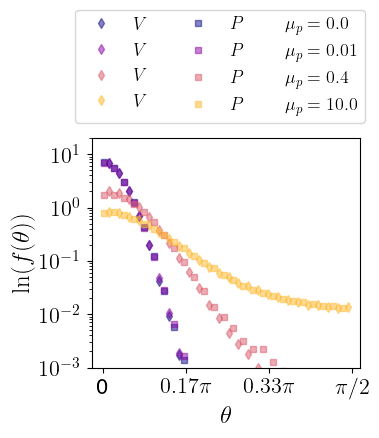

In [5]:
aspect_ratios = np.array([5.0])

directories = ["output_data_volume", "output_data_hertz"]
marke_list = ['d', 's']
label_list = ['$V$', '$P$']

thetas = np.linspace(0, np.pi / 2, 200)
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0]
num_cofs = len(cofs)
cmap = plt.cm.plasma
length_cmap = cmap.N
if num_cofs > 1:
    delta_color = np.floor(length_cmap / (num_cofs-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_cofs)]

I=0.1

fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for jj, directory in enumerate(directories):

    for kk, cof in enumerate(cofs):
        if kk % 2 == 0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
            if jj == 1:
                axes.semilogy(bin_centers[0, ::4], pdf_data[0, ::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]} \\qquad $\\mu_p={cof}$')
            else:
                axes.semilogy(bin_centers[0, 2::4], pdf_data[0, 2::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
axes.set_xlabel('$\\theta$', fontsize=18)
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.set_ylim(1e-3, 20)
axes.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
axes.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
axes.legend(ncols=2, fontsize=13, bbox_to_anchor=(1.05, 1.6))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# # Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
# norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
# sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
# sm.set_array([])  # Needed only for matplotlib < 3.1

# # Add colorbar above the subplots
# cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
# cbar.set_label(r'$\alpha$', fontsize=24)
# cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes.set_ylabel(r'$\ln(f(\theta))$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_volume.pdf", dpi=300, bbox_inches='tight')
plt.show()

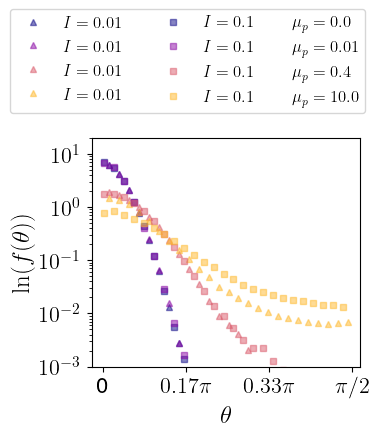

In [6]:
aspect_ratios = np.array([5.0])

directory = "output_data_hertz"
marke_list = ['^', 's']
label_list = ['$I=0.01$', '$I=0.1$']

thetas = np.linspace(0, np.pi / 2, 200)
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0]
num_cofs = len(cofs)
cmap = plt.cm.plasma
length_cmap = cmap.N
if num_cofs > 1:
    delta_color = np.floor(length_cmap / (num_cofs-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_cofs)]

Is=[0.01, 0.1]

fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=Tru)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for jj, I in enumerate(Is):

    for kk, cof in enumerate(cofs):
        if kk%2==0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

            if jj == 1:
                axes.semilogy(bin_centers[0, ::4], pdf_data[0, ::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]} \\qquad $\\mu_p={cof}$')
            else:
                axes.semilogy(bin_centers[0, 2::4], pdf_data[0, 2::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
axes.set_xlabel('$\\theta$', fontsize=18)
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.set_ylim(1e-3, 20)
axes.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
axes.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
axes.legend(ncols=2, fontsize=12, bbox_to_anchor=(1.05, 1.6))

# Set common Y label
axes.set_ylabel(r'$\ln(f(\theta))$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_inertial_number.pdf", dpi=300, bbox_inches='tight')
plt.show()

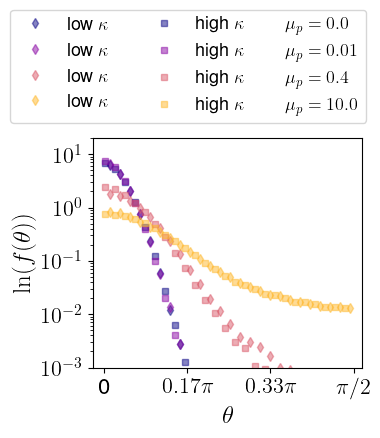

In [7]:
aspect_ratios = np.array([5.0])

directories = ["output_data_hertz", "output_data_high_kappa"]
marke_list = ['d', 's']
label_list = ['low $\\kappa$', 'high $\\kappa$']

thetas = np.linspace(0, np.pi / 2, 200)
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0]
num_cofs = len(cofs)
cmap = plt.cm.plasma
length_cmap = cmap.N
if num_cofs > 1:
    delta_color = np.floor(length_cmap / (num_cofs-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_cofs)]

I=0.1

fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for jj, directory in enumerate(directories):

    for kk, cof in enumerate(cofs):
        if kk % 2 == 0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
            if jj == 1:
                axes.semilogy(bin_centers[0, 0::4], pdf_data[0, 0::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]} \\qquad $\\mu_p={cof}$')
            else:
                axes.semilogy(bin_centers[0, 2::4], pdf_data[0, 2::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
axes.set_xlabel('$\\theta$', fontsize=18)
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.set_ylim(1e-3, 20)
axes.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
axes.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
axes.legend(ncols=2, fontsize=13, bbox_to_anchor=(1.05, 1.6))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# Set common Y label
axes.set_ylabel(r'$\ln(f(\theta))$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_high_kappa.pdf", dpi=300, bbox_inches='tight')
plt.show()

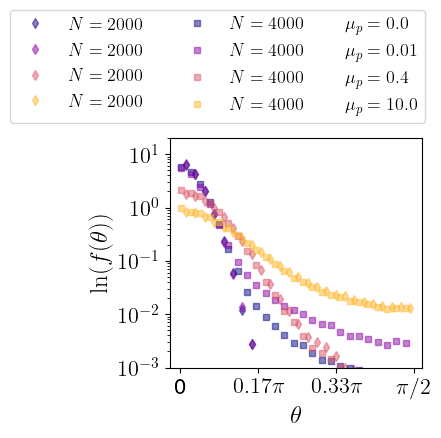

In [48]:
aspect_ratios = np.array([5.0])

directories = ["output_data_hertz", "output_data_N4000_long_box"]
marke_list = ['d', 's']
label_list = ['$N=2000$', '$N=4000$']

thetas = np.linspace(0, np.pi / 2, 200)
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0]
num_cofs = len(cofs)
cmap = plt.cm.plasma
length_cmap = cmap.N
if num_cofs > 1:
    delta_color = np.floor(length_cmap / (num_cofs-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_cofs)]

I=0.1

fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for jj, directory in enumerate(directories):

    for kk, cof in enumerate(cofs):
        if kk % 2 == 0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
            if jj == 1:
                axes.semilogy(bin_centers[0, 0::4], pdf_data[0, 0::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]} \\qquad $\\mu_p={cof}$')
            else:
                axes.semilogy(bin_centers[0, 2::4], pdf_data[0, 2::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
axes.set_xlabel('$\\theta$', fontsize=18)
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.set_ylim(1e-3, 20)
axes.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
axes.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
axes.legend(ncols=2, fontsize=13, bbox_to_anchor=(1.05, 1.6))

# Set common Y label
axes.set_ylabel(r'$\ln(f(\theta))$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_N4000_long_box.pdf", dpi=300, bbox_inches='tight')
plt.show()

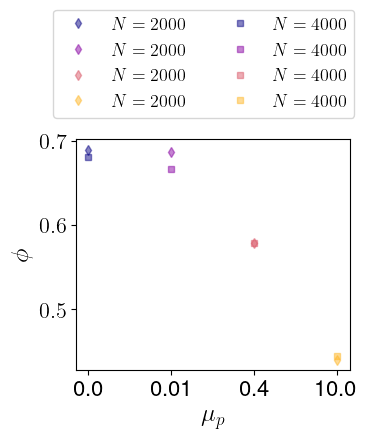

In [56]:
fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=True)
thetas_high_res = np.linspace(0, np.pi/2, 500)

for jj, directory in enumerate(directories):

    for kk, cof in enumerate(cofs):
        if kk % 2 == 0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
            if jj == 1:
                axes.plot(kk, phi, marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')
            else:
                axes.plot(kk, phi, marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.legend(ncols=2, fontsize=13, bbox_to_anchor=(1.05, 1.6))

cofs_used = [0.0, 0.01, 0.4, 10.0]
x_positions = 2*np.arange(len(cofs_used))
# Set common Y label
axes.set_ylabel(r'$\phi$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)
axes.set_xlabel(r'$\mu_p$', fontsize=18)
axes.set_xticks(x_positions)
axes.set_xticklabels([str(c) for c in cofs_used])

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"phi_comparison_N4000_long_box.pdf", dpi=300, bbox_inches='tight')
plt.show()

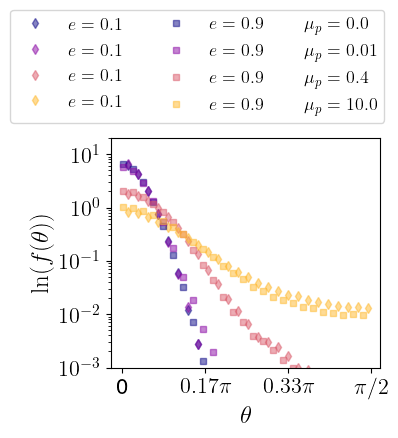

In [10]:
aspect_ratios = np.array([5.0])

directories = ["output_data_hertz", "output_data_e0.9"]
marke_list = ['d', 's']
label_list = ['$e=0.1$', '$e=0.9$']

thetas = np.linspace(0, np.pi / 2, 200)
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0]
num_cofs = len(cofs)
cmap = plt.cm.plasma
length_cmap = cmap.N
if num_cofs > 1:
    delta_color = np.floor(length_cmap / (num_cofs-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_cofs)]

I=0.1

fig, axes = plt.subplots(1, 1, figsize=(4 , 6.0))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for jj, directory in enumerate(directories):

    for kk, cof in enumerate(cofs):
        if kk % 2 == 0:
            # Read data for the current coefficient of friction
            (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
            strains, S2_over_time, times, oacf, tau_r, A_infty, 
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
            if jj == 1:
                axes.semilogy(bin_centers[0, 0::4], pdf_data[0, 0::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]} \\qquad $\\mu_p={cof}$')
            else:
                axes.semilogy(bin_centers[0, 2::4], pdf_data[0, 2::4], marker= marke_list[jj], linestyle='', markersize=5, color=colors[kk], alpha=0.5, 
                        label=f'{label_list[jj]}')

        
axes.set_xlabel('$\\theta$', fontsize=18)
# axes.set_title(f'$\\mu_p = {cof}$', fontsize=25)
axes.set_ylim(1e-3, 20)
axes.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
axes.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
axes.legend(ncols=2, fontsize=13, bbox_to_anchor=(1.05, 1.6))

# Set common Y label
axes.set_ylabel(r'$\ln(f(\theta))$', fontsize=18)
axes.tick_params(axis='both', labelsize=16)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_e0.9.pdf", dpi=300, bbox_inches='tight')
plt.show()

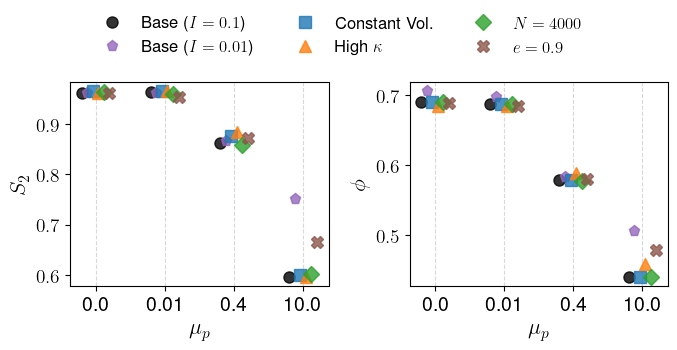

In [11]:
aspect_ratios = np.array([5.0])
cofs = [0.0, 0.01, 0.4, 10.0]

# Add the 'I' parameter directly into the dictionary so you can pull from the same dir twice
checks = [
    {"dir": "output_data_hertz",          "label": "Base ($I=0.1$)",       "marker": "o", "color": "black",       "I": 0.1},
    {"dir": "output_data_hertz",          "label": "Base ($I=0.01$)",      "marker": "p", "color": "tab:purple",  "I": 0.01},
    {"dir": "output_data_volume",         "label": "Constant Vol.",        "marker": "s", "color": "tab:blue",    "I": 0.1},
    {"dir": "output_data_high_kappa",     "label": "High $\\kappa$",       "marker": "^", "color": "tab:orange",  "I": 0.1},
    {"dir": "output_data_N4000",          "label": "$N=4000$",       "marker": "D", "color": "tab:green",   "I": 0.1},
    {"dir": "output_data_e0.9", "label": "$e=0.9$", "marker": "X", "color": "tab:brown", "I": 0.1},
    # {"dir": "output_data_N4000_long_box", "label": "$N=4000$ (Long Box)",  "marker": "v", "color": "tab:red",     "I": 0.1},

]

# Set up categorical x-axis
x_pos = np.arange(len(cofs))
cof_labels = [str(c) for c in cofs]

num_checks = len(checks)
# REDUCED WIDTH: This keeps the clusters tighter so they don't bleed into the next category
width = 0.4 
offsets = np.linspace(-width/2, width/2, num_checks)

# Plot formatting
plt.rc('font', size=14)
plt.rc('axes', titlesize=14, labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

for i, check in enumerate(checks):
    S2_vals = []
    phi_vals = []
    shifted_x = x_pos + offsets[i]
    
    for cof in cofs:
        try:
            # Extract the specific 'I' for this check instead of a global variable
            data = read_pdf_theta(check["dir"], cof, check["I"], aspect_ratios)
            S2_scalar = data[2]
            phi = data[7]
            
            S2_vals.append(np.atleast_1d(S2_scalar)[0])
            phi_vals.append(np.atleast_1d(phi)[0])
        except FileNotFoundError:
            S2_vals.append(np.nan)
            phi_vals.append(np.nan)
            
    # Plot S2
    ax1.plot(shifted_x, S2_vals, marker=check["marker"], linestyle='none', linewidth=1.5, 
             markersize=8, color=check["color"], label=check["label"], alpha=0.8)
    
    # Plot phi
    ax2.plot(shifted_x, phi_vals, marker=check["marker"], linestyle='none', linewidth=1.5, 
             markersize=8, color=check["color"], alpha=0.8)

# Format S2 Subplot (ax1)
ax1.set_ylabel('$S_2$')
ax1.set_xlabel('$\\mu_p$')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(cof_labels)

# Format phi Subplot (ax2)
ax2.set_ylabel('$\\phi$')
ax2.set_xlabel('$\\mu_p$')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(cof_labels)

# Add faint vertical grid lines to explicitly separate the categories
ax1.grid(axis='x', color='gray', linestyle='--', alpha=0.3)
ax2.grid(axis='x', color='gray', linestyle='--', alpha=0.3)


# Add a single legend above the plots to save space
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("robustness_checks_S2_phi.pdf", dpi=300, bbox_inches='tight')
plt.show()

<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_10305/525543236.py:61: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$\phi$')


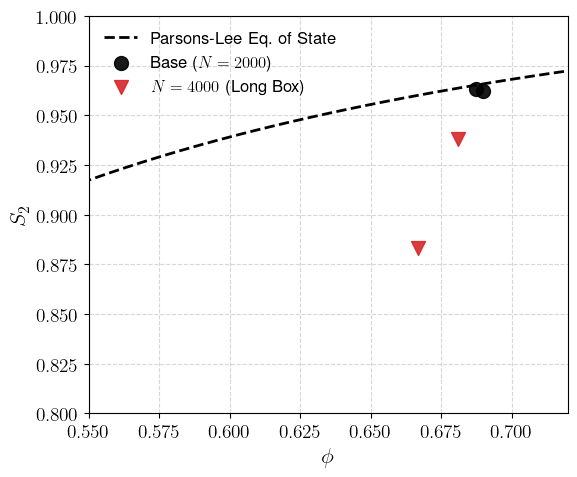

In [12]:
ap = 5.0
# Define a range of phi covering your simulation densities
phi_range = np.linspace(0.4, 0.72, 50) 
S2_theo_curve = np.zeros_like(phi_range)

# Use arbitrary initial guesses for the solver to trace the curve
s2_guess, s4_guess = 0.8, 0.6 

for i, phi_val in enumerate(phi_range):
    correction_density = 1.08 * compute_correction_density(phi_val)
    u2 = correction_density * parsons_volume_approx_p2(ap)
    u4 = correction_density * parsons_volume_approx_p4(ap)
    
    # Solve for theoretical S2
    s2_theo, s4_theo = solve_self_consistent_S2_S4_p4((u2, u4), initial_guesses=(s2_guess, s4_guess))
    S2_theo_curve[i] = s2_theo
    
    # Update guess for the next phi to ensure solver stability along the curve
    s2_guess, s4_guess = s2_theo, s4_theo 

# --- 2. Extract Data for Baseline and Long Box ---
# Focus on the low-friction screening regime where the theory is expected to hold
cofs_screening = [0.0, 0.01] 
I_val = 0.1
aspect_ratios = np.array([ap])

checks_to_plot = [
    {"dir": "output_data_hertz",          "label": "Base ($N=2000$)",      "marker": "o", "color": "black"},
    {"dir": "output_data_N4000_long_box", "label": "$N=4000$ (Long Box)",  "marker": "v", "color": "tab:red"}
]

# --- 3. Plotting ---
plt.rc('font', size=14)
plt.rc('axes', titlesize=14, labelsize=16)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the continuous theoretical EOS
ax.plot(phi_range, S2_theo_curve, 'k--', linewidth=2, label="Parsons-Lee Eq. of State")

# Plot the simulation data
for check in checks_to_plot:
    S2_points = []
    phi_points = []
    
    for cof in cofs_screening:
        try:
            data = read_pdf_theta(check["dir"], cof, I_val, aspect_ratios)
            S2_scalar = np.atleast_1d(data[2])[0]
            phi = np.atleast_1d(data[7])[0]
            
            S2_points.append(S2_scalar)
            phi_points.append(phi)
        except FileNotFoundError:
            pass
            
    # Scatter plot the specific state points
    ax.scatter(phi_points, S2_points, marker=check["marker"], color=check["color"], 
               s=100, label=check["label"], zorder=5, alpha=0.9)

ax.set_xlabel('$\phi$')
ax.set_ylabel('$S_2$')
ax.set_xlim(0.55, 0.72) # Adjust limits to frame the data tightly
ax.set_ylim(0.8, 1.0)
ax.legend(frameon=False)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("EOS_phi_vs_S2_validation.pdf", dpi=300, bbox_inches='tight')
plt.show()

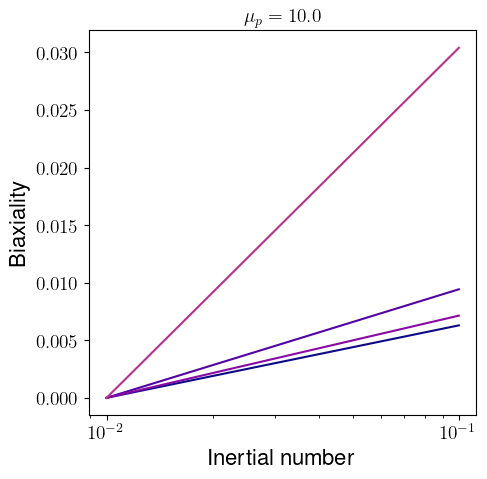

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5 , 5), sharey=True)

for kk, cof in enumerate(cofs):
    biaxialities = []
    for I in Is:
        (
            bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality,
            theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
            rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor,
            strains, S2_over_time, times, oacf, tau_r, A_infty,
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time
        ) = read_pdf_theta(directory, cof, I, aspect_ratios)

        biaxialities.append(biaxiality[0])

    ax.semilogx(Is, biaxialities, linestyle='-', color=colors[kk])
    ax.set_title(rf'$\mu_p={cof}$')
    ax.set_xlabel('Inertial number')
    ax.set_ylabel('Biaxiality')


<>:137: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10305/835819669.py:137: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('$\ln(f(\\theta))$', fontsize=24)
/tmp/ipykernel_10305/1664600854.py:118: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  sol = minimize_scalar(objective_func, bounds=(0.0, 7.0),


Skipping plot for ap=2.0, bad K fit.
Skipping plot for ap=2.0, bad K fit.


/tmp/ipykernel_10305/835819669.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


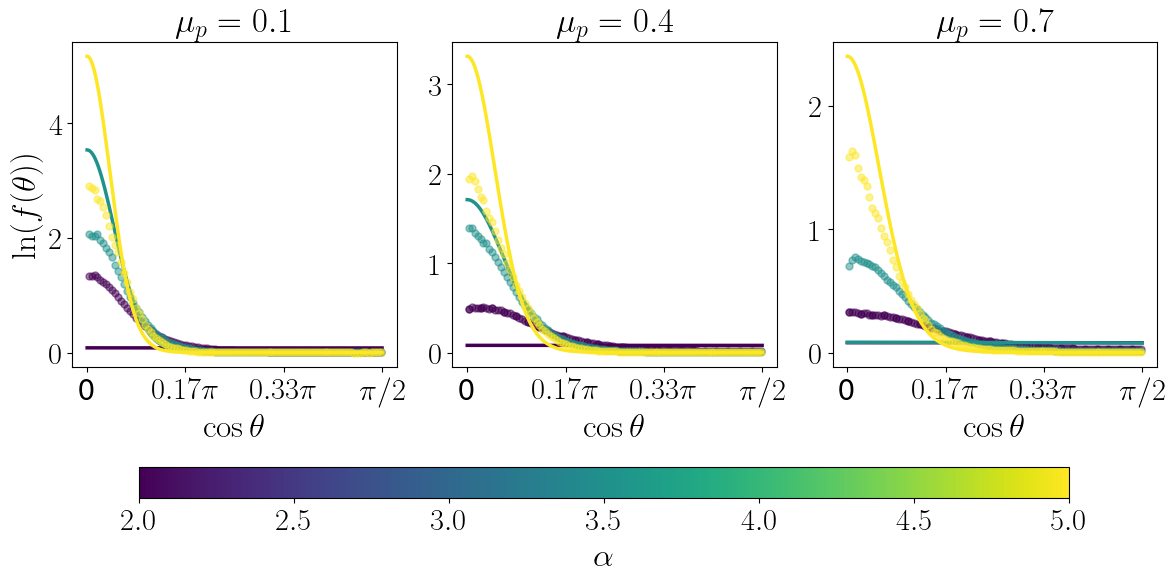

In [14]:
aspect_ratios = np.array([2.0, 3.3, 5.0])

directory = "output_data_rods"

thetas = np.linspace(0, np.pi / 2, 200)
cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
if num_colors > 1:
    delta_color = np.floor(length_cmap / (num_colors-1))
else:
    delta_color = 1
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]

I=0.1
cofs = [0.1, 0.4, 0.7]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(4 * num_cofs, 4))#, sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
     rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
     strains, S2_over_time, times, oacf, tau_r, A_infty, 
     omega, screening_jeffrey, error_screening, angle_over_time,
     theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
    
    U1_self_consistent = np.empty_like(S2_scalar)
    U2_self_consistent = np.empty_like(S4_scalar)   
    U_theo_2 = np.empty_like(S2_scalar)
    U_theo_4 = np.empty_like(S4_scalar)
    U_theo_6 = np.empty_like(S4_scalar)
    S2_scalar_theo = np.empty_like(S2_scalar)
    S4_scalar_theo = np.empty_like(S4_scalar)
    
    for i in range(S2_scalar.shape[0]):
        # Get the scalar values for this iteration
        s2_val = S2_scalar[i]
        s4_val = S4_scalar[i]
        phi_val = phi[i]
        ap = aspect_ratios[i]

        # 1. Calculate the *theoretical* U values from Parsons-Lee
        correction_density = compute_correction_density(phi_val)
        U_theo_2[i] = -correction_density * excluded_volume_rod_P2(ap)
        U_theo_4[i] = -correction_density * excluded_volume_rod_P4(ap)
        U_theo_6[i] = -correction_density * excluded_volume_rod_P6(ap)

        S2_scalar_theo[i], S4_scalar_theo[i] = solve_self_consistent_S2_S4_p4((U_theo_2[i], U_theo_4[i]),
                                                                       initial_guesses=(s2_val, s4_val))

        # print(f"ap={ap}, U_theo_2={U_theo_2:.3f}, U_theo_4={U_theo_4:.3f}")

        # 2. Call the new 1D finder function to get the scaling factor K
        K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val), 
                                        (U_theo_2[i], U_theo_4[i]))
        
        if K_fitted < 0.01:
            K_fitted = np.nan

        # 3. Store the final, scaled U values
        U1_self_consistent[i] = K_fitted * U_theo_2[i]
        U2_self_consistent[i] = K_fitted * U_theo_4[i]

    U1_self_consistents[cofs.index(cof), 0, :] = U1_self_consistent
    U2_self_consistents[cofs.index(cof), 0, :] = U2_self_consistent

    for i, ap in enumerate(aspect_ratios):        
        
        # Get the final fitted U and S parameters
        U_params = (U1_self_consistent[i], U2_self_consistent[i])
        S_params = (S2_scalar[i], S4_scalar[i])

        # Check for bad fits (NaNs)
        if np.isnan(U_params[0]):
            ax.plot(bin_centers[i, ::4], pdf_data[i, ::4], 'o', linestyle='', markersize=5, color=colors[i], alpha=0.5)
            print(f"Skipping plot for ap={ap}, bad K fit.")
            # continue
            
        # Get the ODF using the final fitted parameters
        fitted_odf = fit_equilibrium_ODF_P4(thetas_high_res, S_params, U_params)

        theo_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2_scalar_theo[i], S4_scalar_theo[i]), 
                                          (U_theo_2[i], U_theo_4[i]))

        # Compute RMSE error between measured PDF and fitted ODF
        d_theta = bin_centers[i, 1] - bin_centers[i, 0]
        rmse_error = compute_rmse_error_p4(pdf_data[i, :], U_params, S_params, 
                                           bin_centers[i, :], d_theta, thetas_high_res)
        rmse_self_consistents[cofs.index(cof), 0, i] = rmse_error

        # Plot fitted ODF and PDF data
        # ax.semilogy(thetas_high_res, fitted_odf, label=f'$\\alpha={ap}$', linestyle='-', linewidth=2.5, color=colors[i])
        ax.plot(bin_centers[i, ::1], pdf_data[i, ::1], 'o', linestyle='', markersize=5, color=colors[i], alpha=0.5)
        ax.plot(thetas_high_res, theo_odf, linestyle='-', linewidth=2.5, color=colors[i], alpha=1.0)
        
    # ax.set_ylim(1e-5, 30)
    # ax.set_ylim(1e-5, 30)
    ax.set_xlabel('$\\cos \\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    # ax.set_ylim(1e-3, 20)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
sm.set_array([])  # Needed only for matplotlib < 3.1

# Add colorbar above the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes[0].set_ylabel('$\ln(f(\\theta))$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f"pdf_comparison_rods.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# # compare the measured nematic order parameter with the self-consistent solution using U_fitted

# # Create a new figure for the self-consistency check
# fig_sc, axes_sc = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
# if num_cofs == 1:
#     axes_sc = [axes_sc]

# fig_sc.suptitle('Self-Consistency Check of Maier-Saupe Theory', fontsize=20, y=1.02)

# # Loop through each coefficient of friction
# for ax, cof in zip(axes_sc, cofs):
#     # Read the data for the current coefficient of friction
#     # This call should be identical to the one in your main plotting loop
#     (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
#      theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
#      rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
#      strains, S2_over_time, times, oacf, tau_r, A_infty, 
#      omega, screening_jeffrey, error_screening, angle_over_time,
#      theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

#     # For each aspect ratio, use the fitted U to solve for the self-consistent S2
#     S2_self_consistent = [solve_self_consistent_S2(U) for U in U_fitted]

#     # Plot the S2 measured directly from the simulation particle orientations
#     ax.plot(aspect_ratios, S2_scalar, 'o-', color='black', label='Measured $S_2$')
    
#     # Plot the theoretical S2 that is self-consistent with the fitted U
#     ax.plot(aspect_ratios, S2_self_consistent, 's--', color='red', label='Self-Consistent $S_2$')
    
#     ax.set_title(f'$\\mu_p = {cof}$')
#     ax.set_xlabel('$\\alpha$')
#     ax.set_ylim(0, 1.05)
#     ax.grid(True, linestyle='--')
#     ax.legend()

# # Set common labels and finalize the plot
# axes_sc[0].set_ylabel('$S_2$')
# plt.tight_layout()
# plt.savefig(f"self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
# plt.show()

# # Create a new figure for the inverse self-consistency check
# fig_u, axes_u = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
# if num_cofs == 1:
#     axes_u = [axes_u]

# fig_u.suptitle('Inverse Self-Consistency Check: Comparing U values', fontsize=20, y=1.02)

# # Loop through each coefficient of friction
# for ax, cof in zip(axes_u, cofs):
#     # Read the data for the current coefficient of friction
#     (bin_centers, pdf_data, S2_scalar, biaxiality, 
#      theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
#      rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
#      strains, S2_over_time, times, oacf, tau_r, A_infty, 
#      omega, screening_jeffrey, error_screening, angle_over_time,
#      theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

#     # For each aspect ratio, use the measured S2 to find the self-consistent U
#     U1_self_consistent = [find_U_from_S2(s2) for s2 in S2_scalar]

#     # Plot the U obtained by fitting the distribution's shape
#     ax.plot(aspect_ratios, U_fitted, 'o-', color='black', label='Fitted $U$ (from shape)')
    
#     # Plot the theoretical U that is self-consistent with the measured S2
#     ax.plot(aspect_ratios, U1_self_consistent, 's--', color='red', label='Self-Consistent $U$ (from $S_2$)')
    
#     ax.set_title(f'$\\mu_p = {cof}$')
#     ax.set_xlabel('$\\alpha$')
#     ax.grid(True, linestyle='--')
#     ax.legend()

# # Set common labels and finalize the plot
# axes_u[0].set_ylabel('$U$')
# plt.tight_layout()
# plt.savefig(f"inverse_self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
# plt.show()



In [16]:
aspect_ratios = np.array([2.0, 3.3, 5.0])
Is=[0.1]
cofs = np.array([0.1, 0.4 , 0.7])
# cofs = np.array([0.0, 0.001, 0.01, 0.1, 0.4, 0.7, 1.0, 10.0, 100.0])


biaxiality = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_scalar = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S4_scalar = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S4_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U4_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
theta_d = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U_fitted = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phis = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phi_fluctuations = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
D_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
shear_rates = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
rmse = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n1_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n2_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_yy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_xy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3))
S4_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3, 3, 3))
# Initialize arrays to store strains, S2_over_time, times, and oacf
strains = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
S2_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
biaxiality_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
angle_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
times = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
oacf = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
tau_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
A_infty = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
# Initialize arrays for omega, screening_jeffrey, error_screening, and angle_over_time
omega = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3))
screening_jeffrey = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
error_screening = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
# 
theta_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
std_omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))

rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

loaded=False

try:
    with open(os.path.join(directory, "U_and_rmse_self_consistent_rods.pkl"), 'rb') as f:
        data_loaded = pickle.load(f)
    U1_self_consistents = data_loaded['U1_self_consistents']
    rmse_self_consistents = data_loaded['rmse_self_consistents']
    print("Loaded saved data successfully.")
    loaded=True
except (FileNotFoundError, KeyError):
    print("U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...")
    U1_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    U2_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))  # if you need this too

for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        (bin_centers, pdf_data, S2_scalar_temp, S4_scalar_temp, biaxiality_temp, theta_d_temp,
          U_fitted_temp, phi_temp, phi_fluct_temp, D_r_temp, shear_rate_temp, 
          rmse_temp, n1_diff_temp, n2_diff_temp, p_yy_temp, p_xy_temp, 
          S2_tensor_temp, S4_tensor_temp, 
          strains_temp, S2_over_time_temp, times_temp, oacf_temp, tau_r_temp, A_infty_temp, 
          omega_temp, screening_jeffrey_temp, error_screening_temp, angle_over_time_temp,
            theta_bins_temp, omega_bins_temp, std_omega_bins_temp, biaxiality_over_time_temp
          ) = read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)
        
        for i_alpha in range(len(aspect_ratios)):
            biaxiality[i_cof, i_I, i_alpha] = biaxiality_temp[i_alpha]
            S2_scalar[i_cof, i_I, i_alpha] = S2_scalar_temp[i_alpha]
            S4_scalar[i_cof, i_I, i_alpha] = S4_scalar_temp[i_alpha]
            theta_d[i_cof, i_I, i_alpha] = theta_d_temp[i_alpha]
            U_fitted[i_cof, i_I, i_alpha] = U_fitted_temp[i_alpha]
            phis[i_cof, i_I, i_alpha] = phi_temp[i_alpha]
            phi_fluctuations[i_cof, i_I, i_alpha] = phi_fluct_temp[i_alpha]
            D_r[i_cof, i_I, i_alpha] = D_r_temp[i_alpha]
            shear_rates[i_cof, i_I, i_alpha] = shear_rate_temp[i_alpha]
            rmse[i_cof, i_I, i_alpha] = rmse_temp[i_alpha]
            n1_diff[i_cof, i_I, i_alpha] = n1_diff_temp[i_alpha]
            n2_diff[i_cof, i_I, i_alpha] = n2_diff_temp[i_alpha]
            p_yy[i_cof, i_I, i_alpha] = p_yy_temp[i_alpha]
            p_xy[i_cof, i_I, i_alpha] = p_xy_temp[i_alpha]
            S2_tensor[i_cof, i_I, i_alpha, :, :] = S2_tensor_temp[i_alpha, :, :]
            S4_tensor[i_cof, i_I, i_alpha, :, :, :, :] = S4_tensor_temp[i_alpha, :, :, :, :]
            strains[i_cof, i_I, i_alpha, :len(strains_temp[i_alpha])] = strains_temp[i_alpha]
            S2_over_time[i_cof, i_I, i_alpha, :len(S2_over_time_temp[i_alpha])] = S2_over_time_temp[i_alpha]
            biaxiality_over_time[i_cof, i_I, i_alpha, :len(biaxiality_over_time_temp[i_alpha])] = biaxiality_over_time_temp[i_alpha]
            times[i_cof, i_I, i_alpha, :len(times_temp[i_alpha])] = times_temp[i_alpha]
            oacf[i_cof, i_I, i_alpha, :len(oacf_temp[i_alpha])] = oacf_temp[i_alpha]
            tau_r[i_cof, i_I, i_alpha] = tau_r_temp[i_alpha]
            A_infty[i_cof, i_I, i_alpha] = A_infty_temp[i_alpha]
            omega[i_cof, i_I, i_alpha, :] = omega_temp[i_alpha, :]
            screening_jeffrey[i_cof, i_I, i_alpha] = screening_jeffrey_temp[i_alpha]
            error_screening[i_cof, i_I, i_alpha] = error_screening_temp[i_alpha]
            angle_over_time[i_cof, i_I, i_alpha, :len(angle_over_time_temp[i_alpha])] = angle_over_time_temp[i_alpha]
            theta_bins[i_cof, i_I, i_alpha, :] = theta_bins_temp[i_alpha, :]
            omega_bins[i_cof, i_I, i_alpha, :] = omega_bins_temp[i_alpha, :] * shear_rate_temp[i_alpha]**2
            std_omega_bins[i_cof, i_I, i_alpha, :] = std_omega_bins_temp[i_alpha, :]
            if not loaded:
                s2_val = S2_scalar_temp[i_alpha]
                s4_val = S4_scalar_temp[i_alpha]
                phi_val = phi_temp[i_alpha]
                ap = aspect_ratios[i_alpha]

                correction_density = compute_correction_density(phi_val)
                U_theo_2 = -correction_density * excluded_volume_rod_P2(ap)
                U_theo_4 = -correction_density * excluded_volume_rod_P4(ap)

                K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val), 
                                                (U_theo_2, U_theo_4))
                
                S2_scalar_theoretical[i_cof, i_I, i_alpha], S4_scalar_theoretical[i_cof, i_I, i_alpha] = solve_self_consistent_S2_S4_p4((U_theo_2, U_theo_4), initial_guesses=(s2_val, s4_val))

                print(f"ap={ap}, U_theo_2={U_theo_2:.3f}, S2_theo={S2_scalar_theoretical[i_cof, i_I, i_alpha]:.3f}")

                if K_fitted < 0.01:
                    K_fitted = np.nan
                U1_self_consistent = K_fitted * U_theo_2
                U2_self_consistent = K_fitted * U_theo_4

                U1_self_consistents[i_cof, i_I, i_alpha] = U1_self_consistent
                U2_self_consistents[i_cof, i_I, i_alpha] = U2_self_consistent

                d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]
                
                U2_theoretical[i_cof, i_I, i_alpha] = U_theo_2
                U4_theoretical[i_cof, i_I, i_alpha] = U_theo_4

                rmse_error = compute_rmse_error_p4(
                    pdf_data=pdf_data[i_alpha, :],
                    interaction_params=(U1_self_consistent, U2_self_consistent),
                    order_params=(s2_val, s4_val),
                    bin_centers=bin_centers[i_alpha, :],
                    bin_width=d_theta,
                    thetas_high_res=thetas_high_res 
                )
                rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error
            # if not loaded:
            #   U1_self_consistent, U2_self_consistent = find_U_from_S2_S4_p4((S2_scalar_temp[i_alpha], S4_scalar_temp[i_alpha]))
            #   U1_self_consistents[i_cof, i_I, i_alpha] = U1_self_consistent[i_alpha]
            #   U2_self_consistents[i_cof, i_I, i_alpha] = U2_self_consistent[i_alpha]
            #   d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]
            #   rmse_error = compute_rmse_error(pdf_data[i_alpha, :], U1_self_consistent[i_alpha], S2_scalar_temp[i_alpha], bin_centers[i_alpha, :], d_theta)
            #   rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error

# save U1_self_consistent and rmse_self_consistent to a pickle file
output_filename = os.path.join(directory, "U_and_rmse_self_consistent_rods.pkl")
with open(output_filename, 'wb') as f:
    pickle.dump({
        'U1_self_consistents': U1_self_consistents,
        'U2_self_consistents': U2_self_consistents,
        'rmse_self_consistents': rmse_self_consistents
    }, f)

   

Loaded saved data successfully.


U_experimental self consistent: [4.48641904 5.70109597 7.09517206]


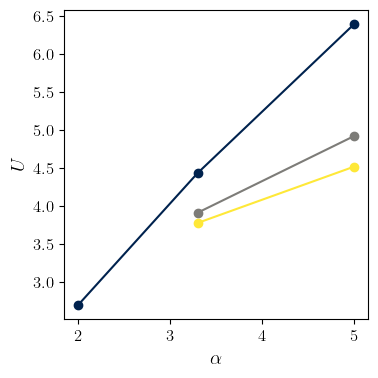

In [17]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.cividis
num_cofs = len(cofs)

# U_experimental = np.array([1.2512, 4.108, 5.747])
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

U_experimental = np.array([find_U_from_S2(s2) for s2 in S2_experimental])
print("U_experimental self consistent:", U_experimental)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    # plt.plot(
    #     alpha_experimental,
    #     4/3*U_experimental/phi_experimental,
    #     's',
    #     label='Experimental data',
    #     color='black'
    # )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    # plt.ylabel("$U  / (\\eta(\\phi) V_{{excl}}) $")#\\phi$")
    plt.ylabel("$U $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    # plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.ylim(0, 2)
    # plt.xlim(1.5, 6.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    # plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_unscaled.png", dpi=300, bbox_inches='tight')
    plt.show()

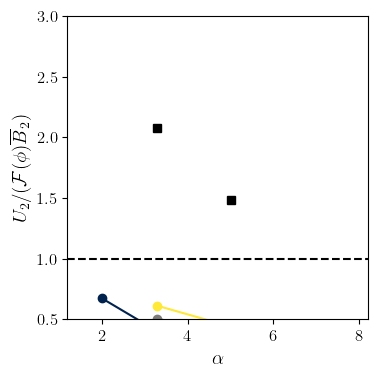

In [18]:
U1_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
    # volume_excluded = -second_coeff_excluded_volume(eccentricity)
    volume_excluded = parsons_volume_approx_p2(aspect_ratios)
    volume_excluded_p4 = parsons_volume_approx_p4(aspect_ratios)


    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = compute_correction_density(phi_dense)
        U1_theoretical[i_cof, i_I, :] = volume_excluded * correction_density * 1.08
        U2_theoretical[i_cof, i_I, :] = volume_excluded_p4 * correction_density * 1.08
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :] / U1_theoretical[i_cof, i_I, :],
            # U2_self_consistents[i_cof, i_I, :] / U2_theoretical[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$U_2  / (\\mathcal{{F}}(\\phi) \\overline{{B}}_{{2}}) $")#\\phi$")
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    plt.ylim(0.5, 3.0)
    plt.xlim(1.2, 8.2)
    plt.tight_layout()
    plt.savefig(f"U_fitted_scaled_vs_alpha_5.0_volume.pdf", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_10305/178955513.py:14: RuntimeWarning: invalid value encountered in sqrt
  alphas_jeffrey = np.sqrt((1 + beta_jeffrey) / (1-beta_jeffrey))


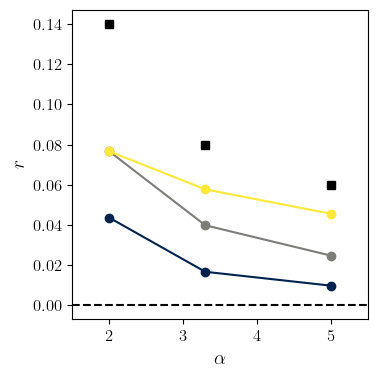

In [19]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

# load csv file
data_pure_jeffrey = np.loadtxt("biaxiality_jeffrey.csv", delimiter=",", skiprows=0) 

beta_jeffrey = data_pure_jeffrey[:, 0]
biaxiality_jeffrey = data_pure_jeffrey[:, 1]
alphas_jeffrey = np.sqrt((1 + beta_jeffrey) / (1-beta_jeffrey))

cmap = plt.cm.cividis
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot Jeffrey's prediction
    # plt.plot(alphas_jeffrey, biaxiality_jeffrey, '-', color='gray', label="Jeffrey's prediction")

    # Plot experimental data
    plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    # plt.title(f"Biaxiality vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    # plt.ylabel("$\\lambda_2-\\lambda_3$")
    plt.ylabel("$r$")
    # plt.ylim(-0.0, 0.33)
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    # plt.axhline(0.5, color='k', linestyle=':', linewidth=1.5, label="Maximum biaxiality")  
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(2.0, 0.6), fontsize=10)
    # plt.grid(True)
    plt.tight_layout()
    plt.xlim(1.5, 5.5)
    plt.savefig(f"biaxiality_vs_alpha_I_{I_val}_rods.pdf", dpi=300, bbox_inches='tight')
    plt.show()



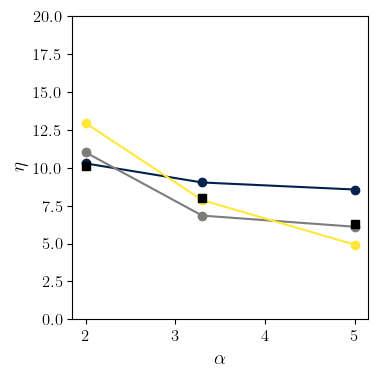

In [20]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
      
    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')


    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    # plt.grid(True)
    plt.ylim([0., 20])
    plt.tight_layout()
    plt.savefig(f"theta_d_vs_alpha_I_{I_val}_rods.pdf", dpi=300, bbox_inches='tight')
    plt.show()



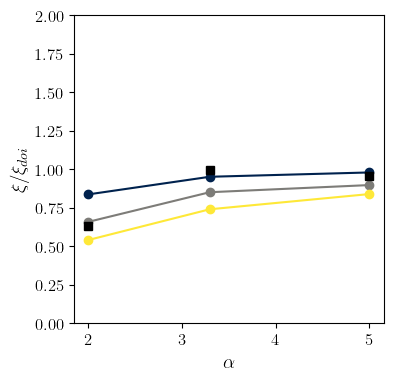

In [21]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        nematic_factor = (2+S2_scalar[i_cof, i_I, :])/(3*S2_scalar[i_cof, i_I, :])
        lambda_derived = nematic_factor
        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            # ell/beta,
            ell/lambda_derived,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
        doi_theory_lambda = beta*(2 + S2_scalar[i_cof, i_I, :]) 

    # plot experimental data
    eccentricity_experimental = np.sqrt(1 - 1 / alphas_rods_experiments**2)
    c_experimental = np.tan(np.deg2rad(theta_d_rods_experiments))**2
    ell_experimental = (+1 + c_experimental) / (1-c_experimental)
    beta_experimental = (alphas_rods_experiments**2 - 1) / (alphas_rods_experiments**2 + 1)
    nematic_factor_experimental = (2+S2_experimental)/(3*S2_experimental)
    lambda_derived_experimental = beta_experimental * nematic_factor_experimental
    plt.plot(
        alphas_rods_experiments,
        # ell_experimental/beta_experimental,
        ell_experimental/lambda_derived_experimental,
        's',
        color='black',
        label='Experiments (rods)'
    )    
    

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\xi / \\xi_{doi}$")
    # plt.legend(title="$\\mu_p =$")
    # plt.grid(True)
    plt.ylim([0., 2])
    # plt.tight_layout()
    plt.savefig(f"ericksen_number_vs_epsilon_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



lambda_doi: 1.2756380415299382 alpha: 2.0 S2: 0.7074852336698412
lambda_doi: 1.104451850533891 alpha: 3.3 S2: 0.8645450106514244
lambda_doi: 1.0673114884362058 alpha: 5.0 S2: 0.9082922455277
lambda_doi: 1.6380971798628816 alpha: 2.0 S2: 0.5109481447082455
lambda_doi: 1.2079736195817155 alpha: 3.3 S2: 0.762218110860429
lambda_doi: 1.1388155414549106 alpha: 5.0 S2: 0.8276615671268085
lambda_doi: 2.0561262465326147 alpha: 2.0 S2: 0.38696854483145365
lambda_doi: 1.4015440886999813 alpha: 3.3 S2: 0.6240965683198378
lambda_doi: 1.2081683465315296 alpha: 5.0 S2: 0.7620484509753289


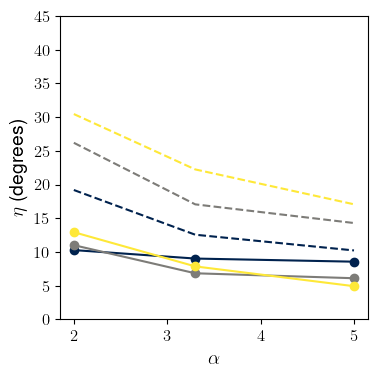

In [22]:
# compare the director angle predicted by doi theory to the measured one

theta_doi = np.zeros_like(theta_d)
for i_cof, cof_val in enumerate(cofs[:]):
    for i_I, I_val in enumerate(Is):
        for i_alpha, alpha_val in enumerate(aspect_ratios):
            beta = (alpha_val**2 - 1) / (alpha_val**2 + 1)
            S2 = S2_scalar[i_cof, i_I, i_alpha]
            nematic_factor = (2 + S2) / (3 * S2)
            lambda_doi =  nematic_factor
            print("lambda_doi:", lambda_doi, "alpha:", alpha_val, "S2:", S2)
            theta_doi[i_cof, i_I, i_alpha] = np.arctan( np.sqrt( (lambda_doi - 1) / (lambda_doi + 1) ) )

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs[:]):
        theta_shifted_measured = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        theta_shifted_doi = np.where(theta_doi[i_cof, i_I, :] < 0, theta_doi[i_cof, i_I, :] + np.pi, theta_doi[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted_measured*180/np.pi,
            label=f"Measured $\\mu_p={cof_val}$",
            color=colors[i_cof],
            marker='o'
        )
        plt.plot(
            aspect_ratios,
            theta_shifted_doi*180/np.pi,
            label=f"DOI Theory $\\mu_p={cof_val}$",
            color=colors[i_cof],
            linestyle='--'
        )
    
    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$ (degrees)")
    plt.ylim([0., 45])
    # plt.legend(bbox_to_anchor=(1.05, 1.0), fontsize=10)
    plt.tight_layout()
    # plt.savefig(f"theta_doi_vs_measured_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



/tmp/ipykernel_10305/2510544922.py:176: RuntimeWarning: divide by zero encountered in divide
  first_factor = 15 / 32 / x**4
/tmp/ipykernel_10305/2510544922.py:177: RuntimeWarning: divide by zero encountered in arctanh
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10305/2510544922.py:177: RuntimeWarning: invalid value encountered in multiply
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10305/2510544922.py:177: RuntimeWarning: invalid value encountered in divide
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10305/2510544922.py:179: RuntimeWarning: divide by zero encountered in divide
  (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
/tmp/ipykernel_10305/2510544922.py:179: RuntimeWarning: invalid value encountered in divide
  (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))


Text(0.5, 1.0, 'Second coefficient of excluded volume as a function of eccentricity')

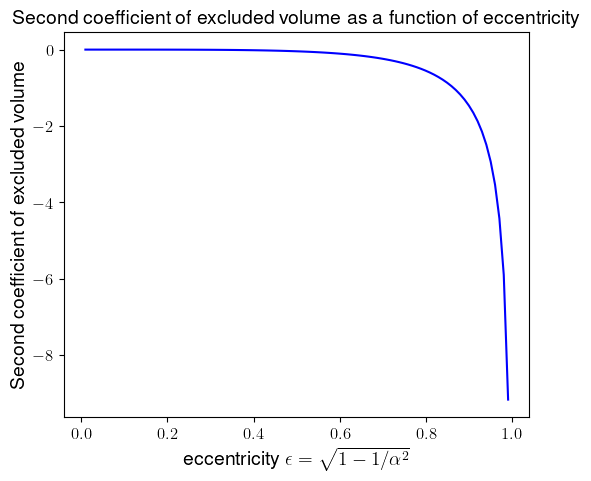

In [23]:
x = np.linspace(0, 1, 100)
plt.figure(figsize=(6, 5))
plt.plot(x, second_coeff_excluded_volume(x), label='Second coefficient of excluded volume', color='blue')
plt.xlabel('eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.ylabel('Second coefficient of excluded volume')
plt.title('Second coefficient of excluded volume as a function of eccentricity')


Text(0.5, 1.0, 'Eccentricity as a function of aspect ratio')

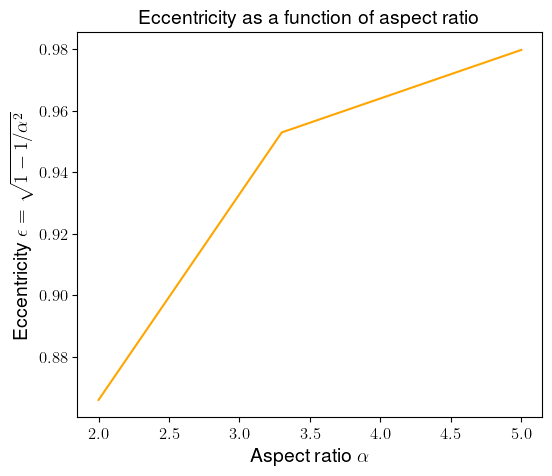

In [24]:
plt.figure(figsize=(6, 5))
plt.plot(aspect_ratios, eccentricity, label='Eccentricity', color='orange')
plt.xlabel('Aspect ratio $\\alpha$')
plt.ylabel('Eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.title('Eccentricity as a function of aspect ratio')

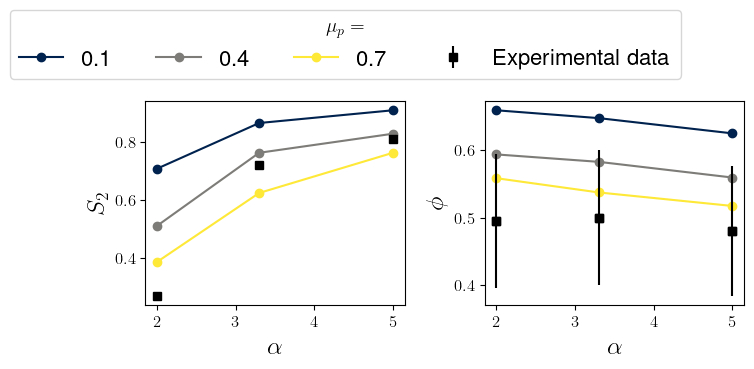

In [25]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[0].plot(
        aspect_ratios,
        S2_scalar[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax[0].plot(alpha_experimental, S2_experimental, 's', label=None, color='black')
ax[1].plot(alpha_experimental, phi_experimental, 's', label=None, color='black')
ax[1].errorbar(alpha_experimental, phi_experimental, yerr=phi_experimental*0.2, fmt='s', color='black', label='Experimental data')
ax[0].set_xlabel(f"$\\alpha$", fontsize=18)
ax[0].set_ylabel("$S_2$", fontsize=18)
# ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel(f"$\\alpha$", fontsize=18)
ax[1].set_ylabel("$\\phi$", fontsize=18)
fig.tight_layout()
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(0.8, 1.5), fontsize=16, ncols=4)
plt.savefig(f"S2_phi_vs_alpha_I_{I}_rods.pdf", dpi=300, bbox_inches='tight')

In [26]:
phis

array([[[0.65877771, 0.6471976 , 0.62464727]],

       [[0.59346873, 0.58252208, 0.55931669]],

       [[0.5582856 , 0.53724356, 0.51725212]]])

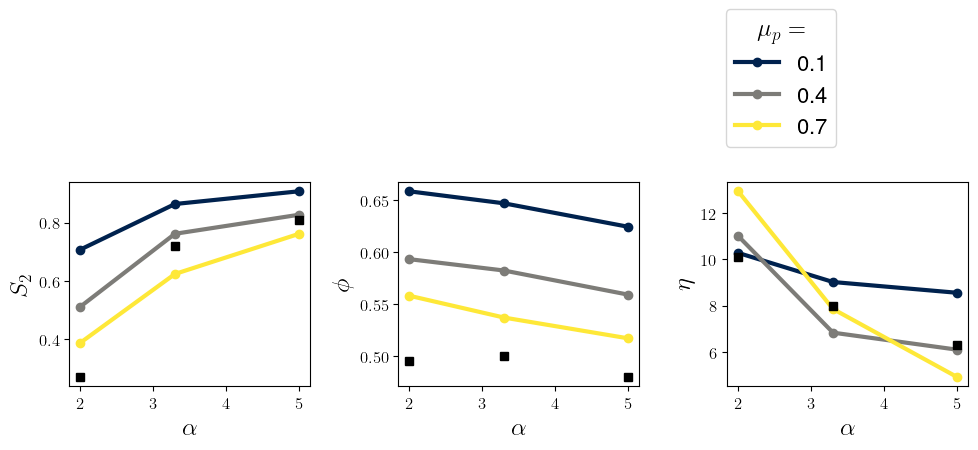

In [27]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1,3, figsize=(10, 3.0))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        S2_scalar[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o',
        linewidth=3
    )
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o',
        linewidth=3
    )
    ax[2].plot(
        aspect_ratios,
        np.rad2deg(theta_d[i_cof, 0, :]),
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o',
        linewidth=3
    )
    

ax[0].plot(alpha_experimental, S2_experimental, 's', label=None, color='black')
ax[1].plot(alpha_experimental, phi_experimental, 's', label=None, color='black')
ax[2].plot(alpha_experimental, theta_d_rods_experiments, 's', label=None, color='black')
# ax[1].errorbar(alpha_experimental, phi_experimental, yerr=phi_experimental*0.1, fmt='s', color='black', label='Experimental data')
ax[0].set_xlabel("$\\alpha$", fontsize=18)
ax[0].set_ylabel("$S_2$", fontsize=18)
# ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel("$\\alpha$", fontsize=18)
ax[1].set_ylabel("$\\phi$", fontsize=18)
ax[2].set_xlabel("$\\alpha$", fontsize=18)
ax[2].set_ylabel("$\\eta$", fontsize=18)
fig.tight_layout()
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(0.5, 1.9), fontsize=16, ncols=1, title_fontsize=18)
plt.savefig(f"S2_eta_vs_alpha_I_{I}_rods.svg", dpi=300, bbox_inches='tight')

In [28]:
for i, alpha in enumerate(aspect_ratios):
    print("alpha:", alpha, "phis:", phis[:, 0, i])

alpha: 2.0 phis: [0.65877771 0.59346873 0.5582856 ]
alpha: 3.3 phis: [0.6471976  0.58252208 0.53724356]
alpha: 5.0 phis: [0.62464727 0.55931669 0.51725212]


In [29]:
for i, alpha in enumerate(aspect_ratios):
    print("alpha:", alpha, "phis:", phis[:, 0, i])
    print("alpha:", alpha, "S2:", S2_scalar[:, 0, i])
    print("alpha:", alpha, "S2_mean:", np.mean(S2_scalar[:, 0, i]))
    

alpha: 2.0 phis: [0.65877771 0.59346873 0.5582856 ]
alpha: 2.0 S2: [0.70748523 0.51094814 0.38696854]
alpha: 2.0 S2_mean: 0.5351339744031801
alpha: 3.3 phis: [0.6471976  0.58252208 0.53724356]
alpha: 3.3 S2: [0.86454501 0.76221811 0.62409657]
alpha: 3.3 S2_mean: 0.7502865632772305
alpha: 5.0 phis: [0.62464727 0.55931669 0.51725212]
alpha: 5.0 S2: [0.90829225 0.82766157 0.76204845]
alpha: 5.0 S2_mean: 0.8326674212099459


Power law fit parameters: a = 0.16630721199179951, b = -1.6327678342217378


Text(0, 0.5, '$D_{r}/ \\dot \\gamma$')

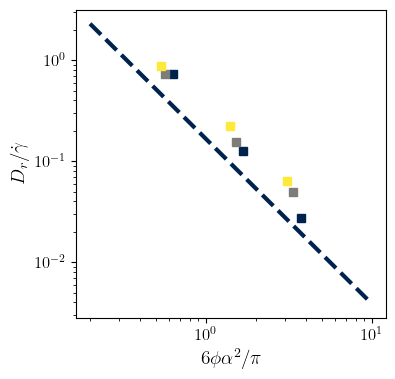

In [30]:
# Power law model: y = a * x^b
def power_law(x, a, c):
    return a *x**c

n_ell_fit = np.linspace(2*10**(-1), 10**1, 100)

# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
Dr_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
max_nell = 0
for i_cof, cof_val in enumerate(cofs):
    V_p = 4 * np.pi * aspect_ratios / 3  # particle volume for prolate ellipsoid
    n_ell3 = phis[i_cof, 0, :] / V_p *aspect_ratios**3
    nem_param = S2_scalar[i_cof, 0, :]
    correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nem_param**2

    max_nell = max(max_nell, np.max(n_ell3))

    ax.loglog(
        n_ell3[:],
        D_r[i_cof, 0, :] * correction_end_end_contact[:]**2/shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof]
    )

    # if cof_val == 0.0:
    # Fit the data
    popt, _ = spo.curve_fit(
        power_law,
        n_ell3[:],
        D_r[0, 0, :] * correction_end_end_contact[:]**2 / shear_rates[0, 0, :],
        p0=[0,0]  # Initial guess for a and b
    )
    
    Dr_theoretical[i_cof, 0, :] = power_law(n_ell3, *popt) * shear_rates[i_cof, 0, :] / correction_end_end_contact**2


correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * S2_scalar[0,0,:]**2
ax.plot(n_ell_fit, power_law(n_ell_fit, *popt), '--', label='Power law fit (frictionless)', linewidth=3, color=colors[0])

# Plot

print(f"Power law fit parameters: a = {popt[0]}, b = {popt[1]}")

ax.set_xlabel("$6 \\phi \\alpha^2 / \\pi$")
ax.set_ylabel("$D_{r}/ \\dot \\gamma$")
# fig.savefig(f"D_r_over_shear_vs_n_ell3_I_{I}.png", dpi=300, bbox_inches='tight')

In [31]:
print(D_r - Dr_theoretical)

[[[-4.56019023e-08  8.73269519e-07 -3.13323668e-06]]

 [[ 1.64686909e-04  4.82276382e-05  2.83831364e-05]]

 [[ 4.23141826e-04  1.50612134e-04  5.66711666e-05]]]


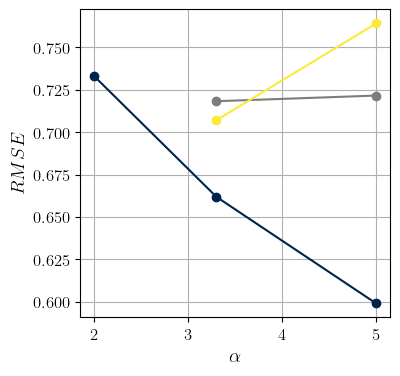

In [32]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        rmse_self_consistents[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$RMSE$")
ax.grid(True)
plt.savefig(f"rmse_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


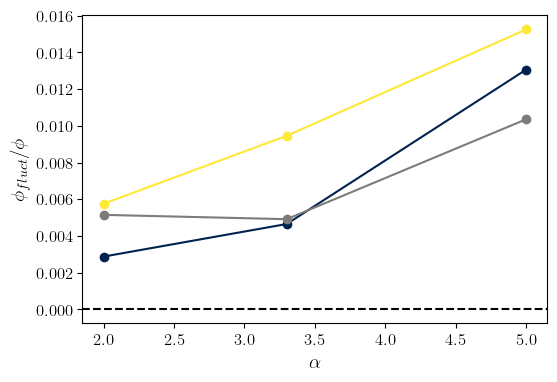

In [33]:
# plot fluctuations of phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        phi_fluctuations[i_cof, 0, :]/phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\phi_{fluct}/\\phi$")
ax.axhline(0.0, color='k', linestyle='--', linewidth=1.5)


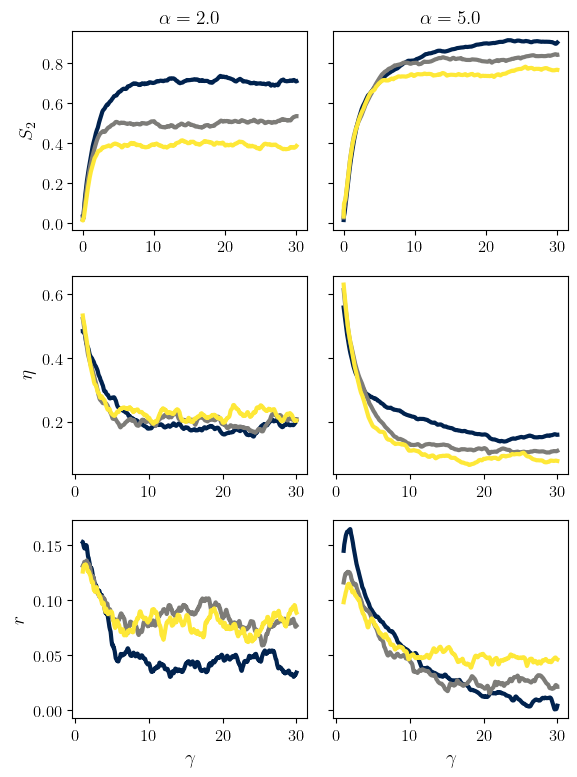

In [34]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [0, 2]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.cividis
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(3, len(alpha_values), figsize=(3*len(alpha_values), 8), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        ax[0][i].plot(
            gamma,
            S2_t,
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[1][i].plot(
            gamma[100:],
            eta[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[2][i].plot(
            gamma[100:],
            biaxiality_t[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )


    ax[0, i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[2, i].set_xlabel("$\\gamma$")

ax[0, 0].set_ylabel("$S_2$")
ax[1, 0].set_ylabel("$\\eta$")
ax[2, 0].set_ylabel("$r$")
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha_rods.svg", dpi=600, bbox_inches='tight')

<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10305/3909810317.py:51: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")


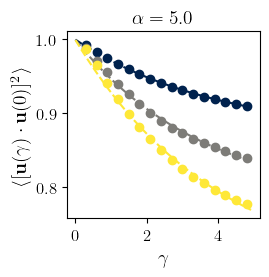

In [35]:
# plot oacf over time

def model_decay(t, tau_r, A_infty):
    return A_infty + (1 - A_infty) * np.exp(-t / tau_r)

alpha_indexs = [2]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.cividis
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if n_plots == 1:
    ax = [ax]

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        t = times[i_cof, 0, alpha_index, :]
        gamma = shear_rates[i_cof, 0, alpha_index] * t
        corr = oacf[i_cof, 0, alpha_index, :]

        t = np.where(t != 0, t, np.nan)  # Replace zeros with NaN for better plotting
        corr = np.where(corr != 0, corr, np.nan)  # Replace zeros with NaN for better plotting
        gamma = np.where(gamma != 0, gamma, np.nan)

        ax[i].plot(
            # t[::30],
            gamma[::30],
            corr[::30],
            'o',
            label=f"{cof_val}",
            color=colors_cof[i_cof]
            # linewidth = 2, 
        )
        # plot the fitted model
        ax[i].plot(
            gamma, 
            model_decay(gamma, tau_r[i_cof, 0, alpha_index]*shear_rates[i_cof, 0, alpha_index], A_infty[i_cof, 0, alpha_index]),
            color=colors_cof[i_cof],
            linestyle='--'
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    # ax[i].set_xlabel("$t$")
    ax[i].set_xlabel("$\\gamma$")

ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")
fig.tight_layout()
# fig.savefig(f"oacf_vs_time_alpha.svg", dpi=300, bbox_inches='tight')
fig.savefig(f"oacf_vs_strain_alpha_rods.svg", dpi=300, bbox_inches='tight')


<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10305/2099438351.py:51: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")


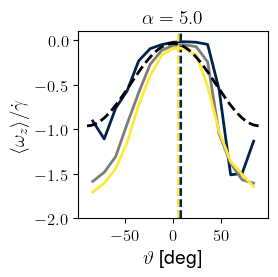

In [36]:
alpha_indexs = [2]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.cividis
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if len(alpha_indexs) == 1:
    ax = [ax]  # Make ax iterable

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        thetas = theta_bins[i_cof, 0, alpha_index, :] * 180/np.pi
        omega_theta = omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]**2
        std_omega_theta = std_omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]
        ax[i].plot(
            thetas,
            omega_theta,
            '-',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 2.0, 
        )
        # ax[i].errorbar(thetas, omega_theta, std_omega_theta, mfc=colors_cof[i_cof],mec=colors_cof[i_cof],
        #          ecolor=colors_cof[i_cof], fmt='o', capsize=5, linestyle='None', linewidth=0.5)
        ax[i].axvline(theta_d[i_cof, 0, alpha_index]*180/np.pi, color=colors_cof[i_cof], linestyle='--', label="$\\eta$")


        ax[i].set_ylim(-2., 0.1)
        
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 200)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
    theta_fit = theta_fit * 180/np.pi

    ax[i].plot(
        theta_fit,
        jeffrey_omega,
        'k--',
        label='Jeffrey',
        linewidth=2
    )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[i].set_xlabel("$\\vartheta$ [deg]")
    
ax[0].set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin_rods.svg", dpi=300, bbox_inches='tight')


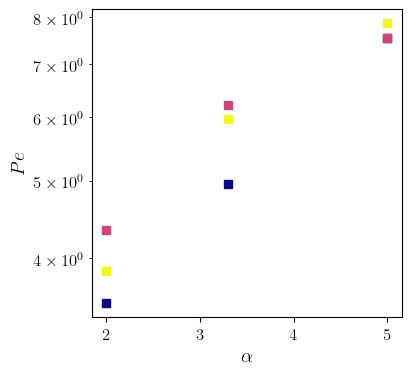

In [37]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    nematic_screening = 2 / 3 * (1-S2_scalar[i_cof, 0, :])
    ax.plot(
        aspect_ratios,
        Pe * nematic_screening,  
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$Pe$")
ax.set_yscale('log')
# ax.set_ylim(0, 100)
fig.savefig(f"Pe_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10305/3606590384.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("$2\omega_z /\dot\gamma \\sqrt{1-\\beta^2}$")


Text(0, 0.5, '$2\\omega_z /\\dot\\gamma \\sqrt{1-\\beta^2}$')

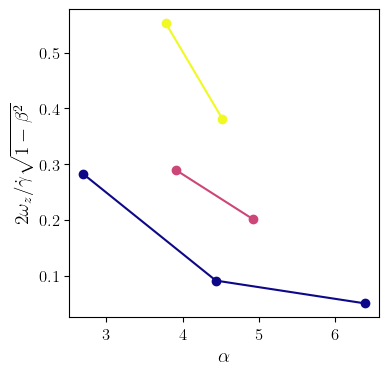

In [38]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

screening_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))

for i_cof, cof_val in enumerate(cofs):
    
    screening_omega[i_cof, 0, :] = - 2*omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :]  / np.sqrt(1 - beta**2)
    beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax.plot(
        U1_self_consistents[i_cof, 0, :],
        - 2*omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :], 
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$2\omega_z /\dot\gamma \\sqrt{1-\\beta^2}$")
# ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")
# ax.grid(True)
# plt.savefig(f"omega_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')


In [39]:
U1_self_consistents

array([[[2.69822643, 4.43688736, 6.39669201]],

       [[       nan, 3.91590321, 4.92473051]],

       [[       nan, 3.78126124, 4.52250731]]])

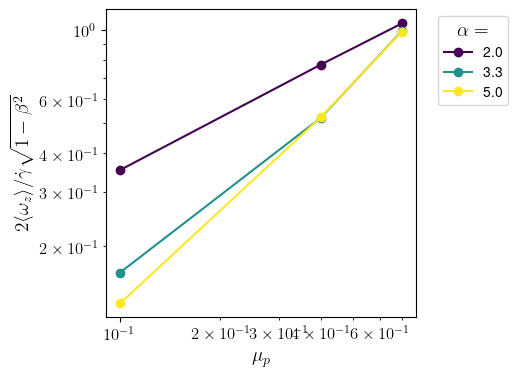

In [40]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):

    ax.loglog(
        np.array(cofs) ,
        screening_omega[:, 0, i_alpha],
        label=f"{alpha_val}",
        color=colors_alpha[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$\\mu_p$")
ax.set_ylabel("$2 \\langle \\omega_z \\rangle / \\dot\\gamma \\sqrt{1-\\beta^2}$")
# ax.set_xlim(-0.01, 0.1)
ax.legend(title="$\\alpha=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)


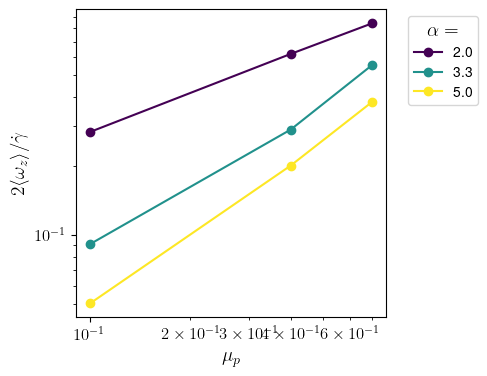

In [41]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):

    ax.loglog(
        cofs ,
        -2 * omega[:, 0, i_alpha, 2] / shear_rates[:, 0, i_alpha] ,
        # - 2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :]/ D_r[i_cof, 0, :], 
        label=f"{alpha_val}",
        color=colors_alpha[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$\\mu_p$")
ax.set_ylabel("$2 \\langle \\omega_z \\rangle / \\dot\\gamma $")
# ax.set_xlim(-0.01, 0.01)
ax.legend(title="$\\alpha=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)


<>:127: SyntaxWarning: invalid escape sequence '\m'
<>:127: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10305/3959868097.py:127: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_p$', fontsize=15)
/tmp/ipykernel_10305/3959868097.py:91: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


Starting individual fits (4-parameter model)...


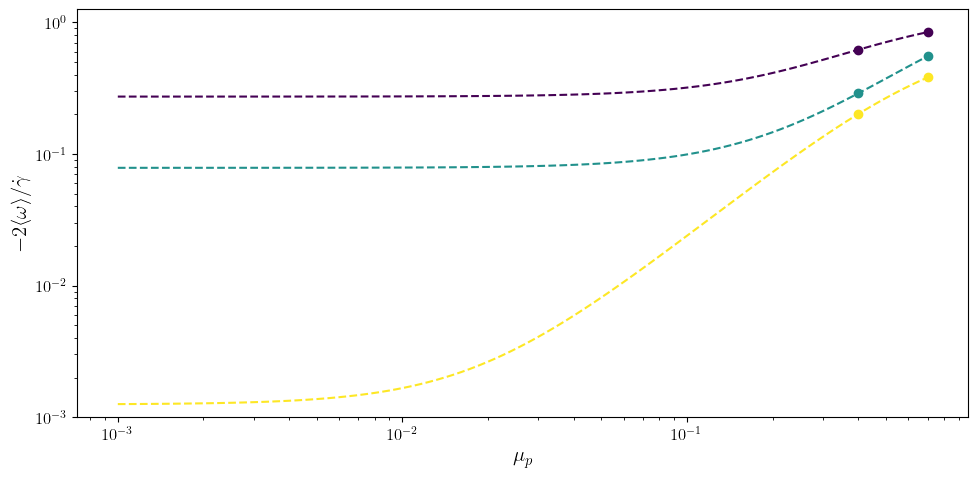


--- All Fit Parameters [A, B, mu_c, k] ---
Alpha  2.0: [0.273, 1.200, 0.537]
Alpha  3.3: [0.078, 1.986, 1.318]
Alpha  5.0: [0.001, 0.829, 0.769]


In [42]:
from scipy.optimize import curve_fit

# --- 1. Define the 5-Parameter Model for a single alpha ---
def simplified_model(mu_p, A, B, mu_c, k):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-k))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def simplified_model_k_fixed(mu_p, A, B, mu_c):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch fixed at 2.5
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-1.75))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def log_model(mu_p, A, B, mu_c, k):
    return np.log(simplified_model(mu_p, A, B, mu_c, k))

def log_model_k_fixed(mu_p, A, B, mu_c):
    return np.log(simplified_model_k_fixed(mu_p, A, B, mu_c))


mu_p_values = cofs

all_fit_parameters = {}
error_bars = {}

plt.figure(figsize=(10, 5))
ax = plt.gca()
colors = plt.cm.viridis(np.linspace(0, 1, len(aspect_ratios)))

betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
y_data_2d = - 2 * omega[1:, 0, :, 2] / shear_rates[1:, 0, :] 
print("Starting individual fits (4-parameter model)...")

# --- 4. Loop, Fit, and Plot ---
for i_alpha, alpha_val in enumerate(aspect_ratios[:]):
    
    x_data_fit = mu_p_values[1:]
    y_data_fit = np.log(y_data_2d[:, i_alpha])
    
    # --- Perform the Fit ---
    # Guesses [A, B, mu_c, k]
    A_guess = max(y_data_fit[0], 1e-9)
    B_guess = max(y_data_fit[-1], 1e-9)

    # p0 = [A_guess, B_guess, 0.5, 2.5]
    p0 = [A_guess, B_guess, 0.5]
    
    # *** CRITICAL FIX: Bounds for A must be positive ***
    # bounds = ([1e-9, 1e-9, 1e-9, 1e-9], [np.inf, np.inf, 5.0, 10.0]) 
    bounds = ([1e-9, 1e-9, 1e-9], [np.inf, np.inf, 5.0]) 

    try:
        popt, pcov = curve_fit(
            log_model_k_fixed,
            # log_model,
            x_data_fit,
            y_data_fit,
            p0=p0,
            bounds=bounds,
            maxfev=5000
        )
        all_fit_parameters[alpha_val] = popt
        perr = np.sqrt(np.diag(pcov))
        error_bars[alpha_val] = perr
        
        mu_fit_line = np.logspace(-3, np.log10(mu_p_values.max()), 100)
        y_vals_fit = log_model_k_fixed(mu_fit_line, *popt)
        # y_vals_fit = log_model(mu_fit_line, *popt)


    except RuntimeError as e:
        print(f"Fit failed for alpha = {alpha_val:.2f}: {e}")
        all_fit_parameters[alpha_val] = [np.nan] * 4
    
    if (i_alpha+1)%1 == 0:
        # Plot original data
        ax.plot(
            x_data_fit, 
            np.exp(y_data_fit), 
            'o', 
            color=colors[i_alpha], 
            label=f"${alpha_val:.1f}$"
        )
        ax.plot(mu_fit_line, np.exp(y_vals_fit), '--', color=colors[i_alpha])

# --- 5. Finalize Plot ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$\mu_p$', fontsize=15)
ax.set_ylabel(r'$-2\langle\omega\rangle / \dot{\gamma}$', fontsize=15)
ax.set_ylim(0.001, y_data_2d.max()*1.5)
# ax.legend(title=r"$\alpha=$", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.title("Data (solid) vs. $ A + (B - A) S(\mu_p) $ fit (dashed)", fontsize=16)
plt.tight_layout()
plt.savefig("omega_fit_vs_mu_p.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.xlim(0, 0.01)
plt.show()

# --- 6. Print Stored Parameters ---
print("\n--- All Fit Parameters [A, B, mu_c, k] ---")
for alpha_val, params in all_fit_parameters.items():
    param_str = ", ".join([f"{p:.3f}" for p in params])
    print(f"Alpha {alpha_val:4.1f}: [{param_str}]")

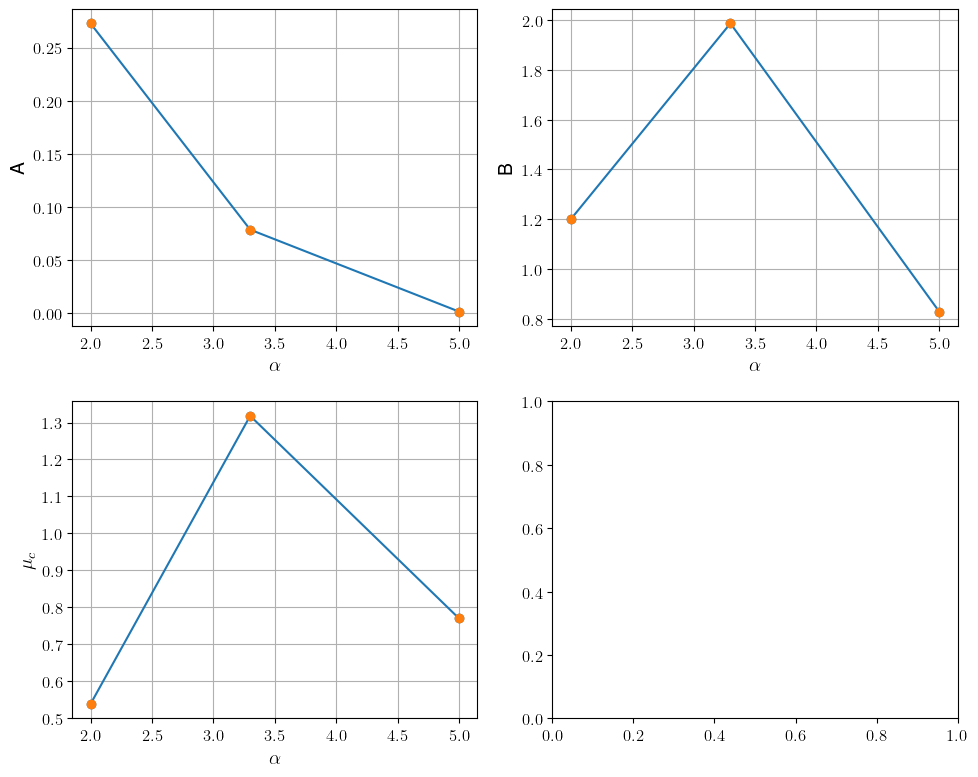

In [43]:
# plot fitted parameters as a function of aspect ratio
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# for i, param_name in enumerate(['A', 'B', r'$\mu_c$', 'k']):
for i, param_name in enumerate(['A', 'B', r'$\mu_c$']):
    ax_i = ax[i // 2, i % 2]
    param_values = [all_fit_parameters[alpha][i] for alpha in aspect_ratios[:]]
    betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax_i.plot(
        aspect_ratios[:],
        # betas[1:],
        param_values,
        'o-'
    )

    # add error bars
    error_values = [error_bars[alpha][i] for alpha in aspect_ratios[:]]
    ax_i.errorbar(
        aspect_ratios[:],
        param_values,
        yerr=error_values,
        fmt='o',
        capsize=5,
        # color='blue'
    )

    ax_i.set_xlabel('$\\alpha$')
    ax_i.set_ylabel(param_name)
    ax_i.grid(True)

plt.tight_layout()
plt.savefig("fit_parameters_vs_alpha_rods.pdf", dpi=300, bbox_inches='tight')

NameError: name 'ratio_omega' is not defined

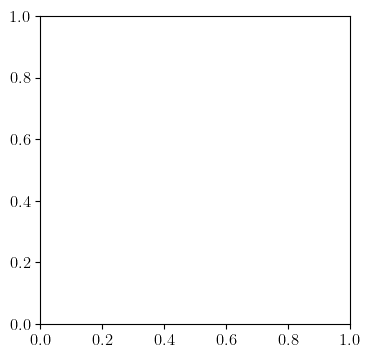

In [44]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

cmap_beta = plt.cm.viridis
colors_beta = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):
    beta = (alpha_val**2 - 1) / (alpha_val**2 + 1)
    cofs = np.array(cofs)
    ax.loglog(
        cofs,
        ratio_omega[:, 0, i_alpha] ,
        label=f"{beta:.2f}",
        color=colors_beta[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$\\mu_p$")
ax.set_ylabel("$\\langle \\omega_z(\\eta) \\rangle / \\omega_z^{{J}}(\\eta)$")
# ax.set_ylim(0.01, 10)
ax.legend(title="$\\beta=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)


<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_19153/3289250721.py:14: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")


Text(0, 0.5, '$2\\omega_z / D_r \\dot\\gamma $')

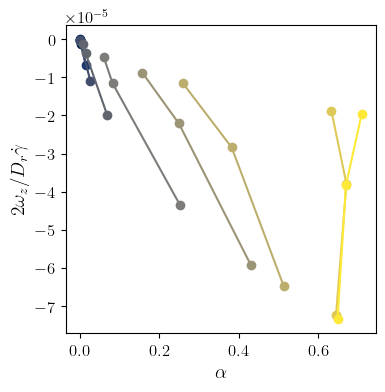

In [ ]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        screening_omega[i_cof, 0, :] * 2 /3 * (1 - S2_scalar[i_cof, 0, :]), 
        2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")
# ax.set_xlim([-0.1, 1.5])
# ax.grid(True)
# plt.savefig(f"omega_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')


In [ ]:
S2_scalar_theoretical

array([[[0.00653001, 0.92523697, 0.9518844 ]],

       [[0.00198982, 0.80250392, 0.92163391]],

       [[0.00190343, 0.01412859, 0.88540784]]])

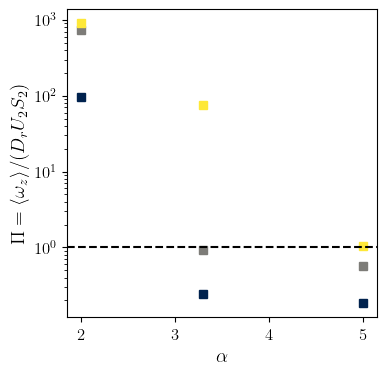

In [ ]:
cmap = plt.cm.cividis
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
Pis = np.zeros((len(cofs), 1, len(aspect_ratios)))
for i_cof, cof_val in enumerate(cofs):
    Pe = -omega[i_cof, 0, :, 2] / (D_r[i_cof, 0, :]) 
    # shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    # nematic_screening = (1-S2_scalar[i_cof, 0, :])
    # Pis[i_cof, 0, :] = Pe / (U1_self_consistents[i_cof, 0, :] * S2_scalar[i_cof, 0, :]) 
    Pis[i_cof, 0, :] = Pe / (S2_scalar_theoretical[i_cof, 0, :] * U1_theoretical[i_cof, 0, :])    
    ax.plot(
        aspect_ratios,
        # Pe/(6*U_fitted[i_cof, 0, :]),
        Pis[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\alpha$")
# ax.set_ylabel("$\\chi Pe/ 6 U S_2$")
ax.set_ylabel("$\\Pi = \\langle \\omega_z \\rangle / (D_r U_2 S_2)$")
# ax.set_ylabel("$\\Pi =  \\chi (1 -S_2)/ ( C U S_2)$")
ax.set_yscale('log')
# ax.set_ylim(0.0001, 200)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")
fig.savefig(f"Pe_screened_vs_alpha_I_{I}_rods.pdf", dpi=300, bbox_inches='tight')

In [ ]:
S2_scalar_theoretical

array([[[0., 0., 0.]],

       [[0., 0., 0.]],

       [[0., 0., 0.]]])

<>:20: SyntaxWarning: invalid escape sequence '\P'
<>:20: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_19153/4039167012.py:20: SyntaxWarning: invalid escape sequence '\P'
  ax.set_xlabel("$\Pi$")


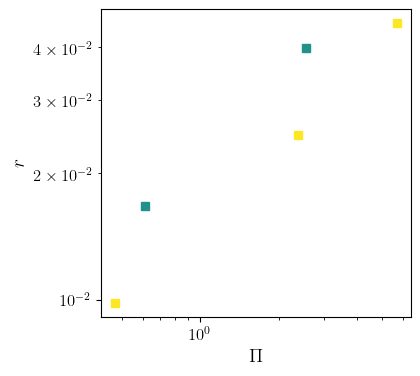

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)

large_aspect_ratios = aspect_ratios[aspect_ratios >= 2.0]
cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(large_aspect_ratios) - 1)) for i in range(len(large_aspect_ratios))]

for i_alpha, alpha in enumerate(large_aspect_ratios):
    i_alpha2 = np.where(aspect_ratios == alpha)[0][0]
    ax.loglog(
        Pis[:, 0, i_alpha2] ,  # modified Peclet number|
        biaxiality[:, 0, i_alpha2],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{alpha}",
        color=colors_alpha[i_alpha]
    )


# ax.legend(title="$\\alpha$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
ax.set_xlabel("$\Pi$")
# ax.set_ylabel("$\\lambda_2- \\lambda_3$")
ax.set_ylabel("$r$")
# ax.set_xlim(0.001, 10)
plt.savefig(f"biaxiality_vs_Pi.pdf", dpi=300, bbox_inches='tight')

(0.0001, 10.0)

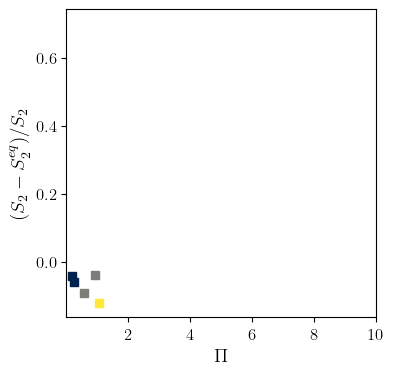

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    normalized_delta_s2 = S2_scalar[i_cof, 0, :] - S2_scalar_theoretical[i_cof, 0, :]
    ax.plot(
        Pis[i_cof, 0, :],
        normalized_delta_s2,
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
    
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\Pi$")
ax.set_ylabel("$(S_2 - S_2^{eq})/S_2$")
ax.set_xlim(0.0001, 10)
ax.set_ylim(-0.5, 0.5)
# plt.savefig(f"biaxiality_vs_Pi.png", dpi=300, bbox_inches='tight')

In [ ]:
delta_s2 = S2_scalar[:, 0, :] - S2_scalar_theoretical[:, 0, :]
print(delta_s2)
print(Pis)  


[[ 0.70095522 -0.06069196 -0.04359215]
 [ 0.50895832 -0.04028581 -0.09397234]
 [ 0.38506512  0.60996797 -0.12335939]]
[[[9.72728802e+01 2.44844449e-01 1.82242573e-01]]

 [[7.43852787e+02 9.09277639e-01 5.67257410e-01]]

 [[8.98287482e+02 7.54410380e+01 1.03988551e+00]]]


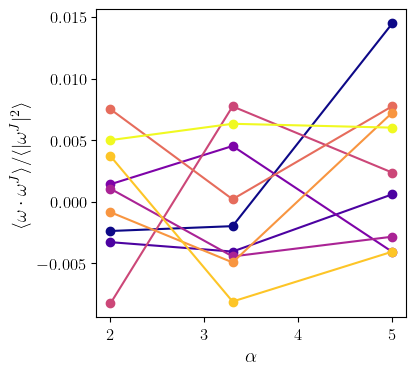

In [ ]:


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for i_cof, cof_val in enumerate(cofs):
   
    ax.plot(
        aspect_ratios,
        screening_jeffrey[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega \\cdot \\omega^J \\rangle / \\langle |\\omega^J|^2 \\rangle $")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"corelation_full_{I}.png", dpi=300, bbox_inches='tight')

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_19153/2874984403.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")


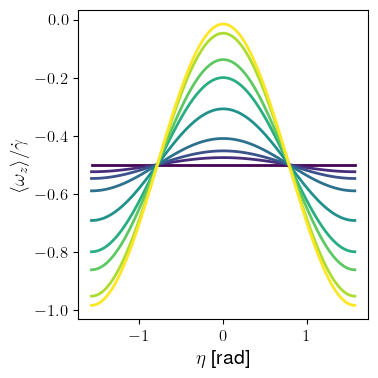

In [ ]:
alpha_values = np.array([1.00, 1.05, 1.1, 1.2, 1.5, 2.0, 2.5, 4.5, 8.0])
cmap = plt.cm.viridis
colors_alpha = [cmap(i / (len(alpha_values) - 1)) for i in range(len(alpha_values))]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

thetas = np.linspace(-np.pi/2, np.pi/2, 200)
for i, alpha_index in enumerate(alpha_values):
    
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 100)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
        
    ax.plot(
        theta_fit,
        jeffrey_omega,
        color=colors_alpha[i],
        label='Jeffrey',
        linewidth=2
    )

    ax.set_xlabel("$\\eta$ [rad]")
    
ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin_pure_jeffrey.svg", dpi=300, bbox_inches='tight')


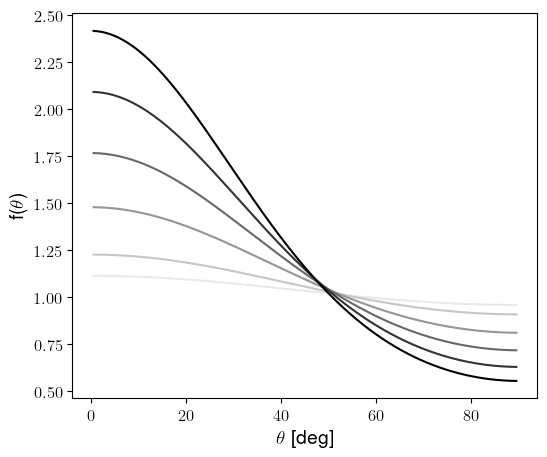

In [ ]:
# plot a generic maier saupe distribution for different S2 values

plt.figure(figsize=(6, 5))
thetas = np.linspace(0.01, np.pi/2-0.01, 200)

S2_values = [0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.98]

cmap = plt.cm.Grays

colors_S2 = [cmap(i / (len(S2_values) - 1)) for i in range(len(S2_values))]
for i, S2 in enumerate(S2_values):
    exponent = (3 * np.cos(thetas)**2 - 1) * S2 / 2
    distribution = np.exp(exponent)
    distribution /= np.trapezoid(distribution*np.sin(thetas), thetas)  # Normalize the distribution

    plt.plot(thetas*180/np.pi, distribution, label=f"$S_2 = {S2}$", color=colors_S2[i])

plt.xlabel("$\\theta$ [deg]")
plt.ylabel("f($\\theta$)")
plt.savefig(f"maier_saupe_distribution.svg", dpi=300, bbox_inches='tight')

In [ ]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(1, len(alpha_values), figsize=(4*len(alpha_values), 4), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        if cof_val <= 0.0:

            ax.plot(
                gamma[100:],
                eta[100:],
                label=f"{cof_val}",
                color=colors_cof[i_cof],
                linewidth = 3, 
                # marker='o'
            )


    ax.set_title(f"$\\alpha = {alpha_values[i]}$")
    ax.set_xlabel("$\\gamma$")

# ax[0, 0].set_ylabel("$S_2$")
ax.set_ylabel("$\\eta$")
# ax.set_ylabel("$\\lambda_2 - \\lambda_3$")
ax.set_ylim([0.15, 0.48])
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha_mup0.svg", dpi=600, bbox_inches='tight')

IndexError: index 5 is out of bounds for axis 0 with size 3

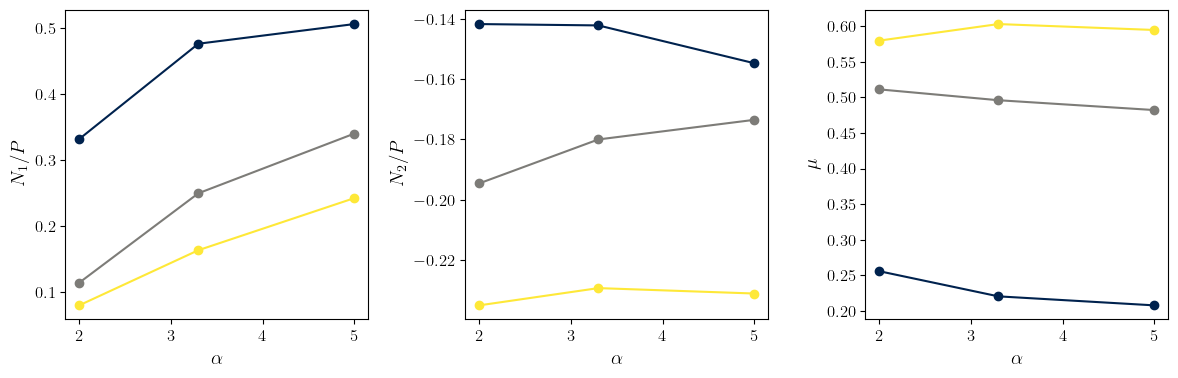

In [ ]:
#plot n1_diff and n2_diff as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        n1_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[1].plot(
        aspect_ratios,
        n2_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[2].plot(
        aspect_ratios,
        p_xy[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )


ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$N_1/P$")
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$N_2/P$")
ax[2].set_xlabel(f"$\\alpha$")
ax[2].set_ylabel("$\\mu$")
fig.tight_layout()


Text(0.5, 0, '$\\alpha$')

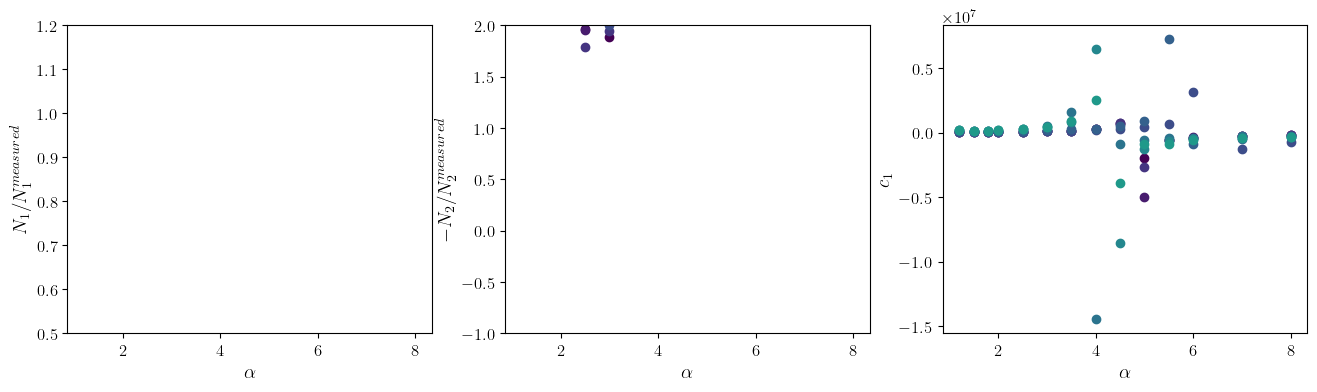

In [ ]:
# for each alpha as a function of cof fit the stress with the pressure and then check the predicted N_1 and N_2 against the computed once

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i_cof, cof in enumerate(cofs):
    const_fits = np.zeros((len(aspect_ratios)))
    n1s_predicted = np.zeros((len(aspect_ratios)))
    n2s_predicted = np.zeros((len(aspect_ratios)))
    n1s_measured = np.zeros((len(aspect_ratios)))
    n2s_measured = np.zeros((len(aspect_ratios)))
    shear_stress_measured = np.zeros((len(aspect_ratios)))
    shear_stress_predicted = np.zeros((len(aspect_ratios)))

    for i_alpha, alpha in enumerate(aspect_ratios):
        n1_measured = n1_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        n2_measured = n2_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        phi_dense = phis[i_cof, 0, i_alpha]
        S2 = S2_tensor[i_cof, 0, i_alpha, :, :]
        S4 = S4_tensor[i_cof, 0, i_alpha, :, :, :, :]

        shear_rate = shear_rates[i_cof, 0, i_alpha]
        strain_tensor = 0.5*np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]]) * shear_rate 
        
        T1 = np.einsum('ijkl, kl->ij', S4, strain_tensor)  # 2nd order tensor
        T2 = np.einsum('ijkl, kl->ij', S4, S2)  
        T3 = S2@S2 
        T_elastic = -(T3 + phi_dense*S2/3 - T2)
        # const_fit = - p_yy[i_cof, 0, i_alpha] / total_stress[0, 0]
        # const_fits[i_alpha] = const_fit
        # stress_model = const_fit * total_stress

        b = np.array([
            p_yy[i_cof, 0, i_alpha],   # measured sigma_yy
            p_xy[i_cof, 0, i_alpha]    # measured sigma_xy
        ])

        A = np.array([
            [T1[1, 1], T_elastic[1, 1]],  # sigma_yy = row 1, col 1
            [T1[0, 1], T_elastic[0, 1]]   # sigma_xy = row 0, col 1 (symm)
        ])

        c1, c2 = np.linalg.solve(A, b)

        stress_model = c1 * T1 + c2 * T_elastic
        const_fits[i_alpha] = c1

        n1_predicted = (stress_model[0,0] - stress_model[1,1]) / p_yy[i_cof, 0, i_alpha]
        n2_predicted = (stress_model[1,1] - stress_model[2,2]) / p_yy[i_cof, 0, i_alpha] 

        n1s_predicted[i_alpha] = n1_predicted
        n2s_predicted[i_alpha] = n2_predicted
        n1s_measured[i_alpha] = n1_measured
        n2s_measured[i_alpha] = n2_measured
        shear_stress_measured[i_alpha] = p_xy[i_cof, 0, i_alpha]
        shear_stress_predicted[i_alpha] = stress_model[0, 1]

    # ax[0].plot(
    #     aspect_ratios,
    #     n1s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[1].plot(
    #     aspect_ratios,
    #     n2s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[2].plot(
    #     aspect_ratios,
    #     const_fits,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[3].plot(
    #     aspect_ratios,
    #     shear_stress_predicted,
    #     '-o',
    #     color=colors[i_cof],)

    ax[0].plot(
        aspect_ratios,
        n1s_predicted/n1s_measured,
        'o',
        color=colors[i_cof],)
    ax[1].plot(
        aspect_ratios,
        -n2s_predicted/ n2s_measured,
        'o',
        color=colors[i_cof],)
    ax[2].plot(
        aspect_ratios,
        const_fits,
        'o',
        color=colors[i_cof],)

ax[0].set_ylim(0.5, 1.2)
ax[1].set_ylim(-1, 2)
ax[0].set_ylabel("$N_1/N_1^{measured}$")
ax[1].set_ylabel("$-N_2/N_2^{measured}$")
ax[2].set_ylabel("$c_1$")
ax[0].set_xlabel("$\\alpha$")
ax[1].set_xlabel("$\\alpha$")
ax[2].set_xlabel("$\\alpha$")

